## 00. load package

In [2]:

import intake
import cartopy.crs as ccrs
import cartopy.feature as cf
import cmocean
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import easygems.healpix as egh
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
from typing import Tuple, List, Optional, Union, Dict
import scipy.signal as signal
from global_land_mask import globe
import math
import time
import os
import pickle
from scipy import fft
import cmaps  
from typing import Optional
import sys
import matplotlib.colors as mcolors
import importlib
sys.path.append("/home/m/m301257/wave_tools")
from wave_tools.utils import dataarray_to_equatorial_latlon_grid,get_region_healpix_,create_cmap_from_string,dataarray_healpix_to_equatorial_latlon
from  wave_tools.plotting import get_cckw_envelope_curve,setup_map_axes,set_axis_for_wave    
# 重新导入修复后的模块
import wave_tools.spectral
import wave_tools.plotting
importlib.reload(wave_tools.spectral)
importlib.reload(wave_tools.plotting)
from wave_tools.spectral import WKSpectralAnalysis, SpectralConfig
from wave_tools.plotting import set_axis_for_wave
from wave_tools import matsuno as mp
print("="*70)
print("✅ 模块重新加载完成")
print("="*70)
import mpi4py
import logging
import glob

DATA_DIR = "./processed_data"
os.makedirs(DATA_DIR, exist_ok=True)
fig_save_dir = "./figures/Cal_MSE/"
os.makedirs(fig_save_dir, exist_ok=True)
print("="*70)
print(f"📁 数据保存目录: {DATA_DIR}")
print(f"📁 图形保存目录: {fig_save_dir}")
def create_improved_colormap():
    from matplotlib.colors import LinearSegmentedColormap
    """创建改进的红-白-蓝配色"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()

✅ 模块重新加载完成
📁 数据保存目录: ./processed_data
📁 图形保存目录: ./figures/Cal_MSE/


In [3]:
# 网格转换参数

def dataarray_to_equatorial_latlon_grid(
    dataarray: xr.DataArray, grid_type: str, grid_dict: Optional[dict]
) -> xr.DataArray:
    """转换数据到赤道经纬度网格"""
    if grid_type == "latlon":
        return dataarray
    elif grid_type == "healpix":
        if grid_dict is None:
            raise ValueError("No grid_dict provided for healpix conversion.")
        return dataarray_healpix_to_equatorial_latlon(dataarray, **grid_dict)
    else:
        raise ValueError("Grid type not found.")




In [4]:
def load_or_process_data(experiment_name, dataset_key, save_path, grid_dict, target_lat, target_lon):
    """
    加载已保存的插值数据，或者处理原始数据并保存
    
    Parameters:
    -----------
    experiment_name : str
        实验名称（用于显示）
    dataset_key : str
        在catalog中的数据集键名
    save_path : str
        保存路径
    grid_dict : dict
        网格转换参数
    target_lat : array
        目标纬度
    target_lon : array
        目标经度
        
    Returns:
    --------
    xr.DataArray : 插值后的数据
    """
    print("="*70)
    print(f"🔄 处理 {experiment_name} 数据...")
    print("="*70)
    
    # 检查是否已存在插值数据
    if os.path.exists(save_path):
        print(f"✅ 发现已保存的插值数据: {save_path}")
        print(f"   正在加载...")
        data_2deg = xr.open_dataarray(save_path)
        print(f"   加载完成! 形状: {data_2deg.shape}")
        return data_2deg
    
    # 如果不存在，则进行处理
    print(f"⚠️  未找到保存的数据，开始处理原始数据...")
    
    # 加载原始数据
    print(f"   1/3 加载原始数据...")
    pr_full = cat.ICON.C5[dataset_key].to_dask()['pr'].sel(time=slice("1980", "1993"))
    print(f"       原始数据形状: {pr_full.shape}")
    
    # 转换到经纬度网格
    print(f"   2/3 转换到经纬度网格...")
    pr_lon_lat = dataarray_to_equatorial_latlon_grid(pr_full, 'healpix', grid_dict)
    print(f"       转换后形状: {pr_lon_lat.shape}")
    
    # 插值到2°x2°
    print(f"   3/3 插值到2°x2°分辨率...")
    data_2deg = pr_lon_lat.interp(lat=target_lat, lon=target_lon, method='linear')
    print(f"       插值后形状: {data_2deg.shape}")
    
    # 保存数据
    print(f"   💾 保存插值数据到: {save_path}")
    data_2deg.to_netcdf(save_path)
    print(f"   ✅ 保存完成!")
    
    return data_2deg

# 设置网格参数（与之前保持一致）
grid_dict = {"nside": 256, "nest": True, "minmax_lat": 16}
target_lat = np.arange(-14, 14.1, 2.0)
target_lon = np.arange(0, 360, 2.0)

print("\n" + "="*70)
print("开始处理三个实验的数据...")
print("="*70)


开始处理三个实验的数据...


In [5]:
def process_var_data(var_name, experiment_name, dataset_key, save_dir, grid_dict, target_lat, target_lon, 
                     has_level=True, level_slice=(30, None)):
    """
    处理变量数据（支持3D和2D），转换网格并插值后保存
    
    Parameters:
    -----------
    var_name : str
        变量名 ('wa', 'hus', 'ta', 'pr')
    experiment_name : str
        实验名称（用于显示）
    dataset_key : str
        在catalog中的数据集键名
    save_dir : str
        保存目录
    grid_dict : dict
        网格转换参数
    target_lat : array
        目标纬度
    target_lon : array
        目标经度
    has_level : bool
        是否为3D数据（有level维度）。True=3D，False=2D
    level_slice : tuple
        level切片范围，仅当has_level=True时有效
    """
    import time
    
    data_type = "3D (多层级)" if has_level else "2D (时间序列)"
    print("="*70)
    print(f"🔄 处理 {var_name.upper()} - {experiment_name} [{data_type}]")
    print("="*70)
    
    # 创建变量和实验的子目录
    if has_level:
        exp_save_dir = os.path.join(save_dir, f"{var_name}_{experiment_name.lower()}_layers")
    else:
        exp_save_dir = os.path.join(save_dir, f"{var_name}_{experiment_name.lower()}")
    os.makedirs(exp_save_dir, exist_ok=True)
    print(f"📁 保存路径: {exp_save_dir}")
    
    # 加载数据（只读取元数据）
    print(f"📖 读取数据元信息...")
    
    if has_level:
        # 3D数据：需要选择level范围
        var_full = cat.ICON.C5[dataset_key].to_dask()[var_name].sel(
            time=slice("1980", "1993"),
            level_full=slice(*level_slice)
        )
        levels = var_full.level_full.values
        n_levels = len(levels)
        
        print(f"✅ 数据信息:")
        print(f"   变量: {var_name}")
        print(f"   时间范围: 1980-1993")
        print(f"   总层数: {n_levels}")
        print(f"   层级范围: {levels[0]:.1f} - {levels[-1]:.1f}")
        print(f"   时间步数: {len(var_full.time)}")
    else:
        # 2D数据：只有时间维度
        var_full = cat.ICON.C5[dataset_key].to_dask()[var_name].sel(
            time=slice("1980", "1993")
        )
        
        print(f"✅ 数据信息:")
        print(f"   变量: {var_name}")
        print(f"   时间范围: 1980-1993")
        print(f"   时间步数: {len(var_full.time)}")
    
    print("="*70)
    
    # 逐层处理（3D）或整体处理（2D）
    total_start_time = time.time()
    
    if has_level:
        # ========== 3D数据：逐层处理 ==========
        for idx, level in enumerate(levels, 1):
            layer_start_time = time.time()
            
            # 构建保存路径
            save_path = os.path.join(exp_save_dir, f"{var_name}_lev_{int(level):03d}.nc")
            
            # 检查是否已处理
            if os.path.exists(save_path):
                print(f"✅ [{idx}/{n_levels}] Level {int(level):3d} - 已存在，跳过")
                continue
            
            print(f"🔄 [{idx}/{n_levels}] 处理 Level {int(level):3d}...")
            
            try:
                # 1. 选择单层数据
                var_layer = var_full.sel(level_full=level)
                print(f"   ├─ 选择层级完成")
                
                # 2. 转换到经纬度网格
                var_lonlat = dataarray_to_equatorial_latlon_grid(var_layer, 'healpix', grid_dict)
                print(f"   ├─ 网格转换完成: {var_lonlat.shape}")
                
                # 3. 插值到2°x2°
                var_2deg = var_lonlat.interp(lat=target_lat, lon=target_lon, method='linear')
                print(f"   ├─ 插值完成: {var_2deg.shape}")
                
                # 4. 转换为Dataset并设置变量名，然后保存
                ds_to_save = var_2deg.to_dataset(name=var_name)
                ds_to_save.to_netcdf(save_path)
                
                # 计算时间
                layer_time = time.time() - layer_start_time
                elapsed_time = time.time() - total_start_time
                avg_time_per_layer = elapsed_time / idx
                remaining_layers = n_levels - idx
                estimated_remaining = avg_time_per_layer * remaining_layers
                
                print(f"   ✅ 保存完成: {os.path.basename(save_path)}")
                print(f"   ⏱️  本层耗时: {layer_time:.1f}s | 平均: {avg_time_per_layer:.1f}s/层")
                print(f"   📊 预计剩余时间: {estimated_remaining/60:.1f} 分钟")
                print()
                
            except Exception as e:
                print(f"   ❌ 处理失败: {str(e)}")
                continue
    
    else:
        # ========== 2D数据：整体处理 ==========
        save_path = os.path.join(exp_save_dir, f"{var_name}_2deg_interp.nc")
        
        # 检查是否已处理
        if os.path.exists(save_path):
            print(f"✅ 数据已存在，跳过处理")
            print(f"   文件: {save_path}")
        else:
            print(f"🔄 开始处理2D数据...")
            
            try:
                # 1. 转换到经纬度网格
                print(f"   ├─ 网格转换中...")
                var_lonlat = dataarray_to_equatorial_latlon_grid(var_full, 'healpix', grid_dict)
                print(f"   ├─ 网格转换完成: {var_lonlat.shape}")
                
                # 2. 插值到2°x2°
                print(f"   ├─ 插值中...")
                var_2deg = var_lonlat.interp(lat=target_lat, lon=target_lon, method='linear')
                print(f"   ├─ 插值完成: {var_2deg.shape}")
                
                # 3. 转换为Dataset并设置变量名，然后保存
                print(f"   ├─ 保存中...")
                ds_to_save = var_2deg.to_dataset(name=var_name)
                ds_to_save.to_netcdf(save_path)
                
                total_time = time.time() - total_start_time
                print(f"   ✅ 保存完成: {os.path.basename(save_path)}")
                print(f"   ⏱️  总耗时: {total_time/60:.1f} 分钟")
                
            except Exception as e:
                print(f"   ❌ 处理失败: {str(e)}")
    
    total_time = time.time() - total_start_time
    print("="*70)
    print(f"✅ {var_name.upper()} - {experiment_name} 处理完成!")
    print(f"   总耗时: {total_time/60:.1f} 分钟")
    print(f"   保存目录: {exp_save_dir}")
    print("="*70)
    print()


In [6]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")

ds = (cat.ICON.C5.AMIP_CNTL.to_dask()).sel(time=slice("1980", "1993"))
ds 


/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 6TB
Dimensions:             (time: 5114, cell: 786432, level_full: 26,
                         level_half: 26)
Coordinates:
  * time                (time) datetime64[ns] 41kB 1980-01-01 ... 1993-12-31
  * level_full          (level_full) float64 208B 14.0 21.0 25.0 ... 89.0 90.0
  * level_half          (level_half) float64 208B 14.0 21.0 25.0 ... 89.0 90.0
    healpix             int64 8B 1
Dimensions without coordinates: cell
Data variables: (12/47)
    clivi               (time, cell) float32 16GB dask.array<chunksize=(128, 16384), meta=np.ndarray>
    cllvi               (time, cell) float32 16GB dask.array<chunksize=(128, 16384), meta=np.ndarray>
    hus2m               (time, cell) float32 16GB dask.array<chunksize=(128, 16384), meta=np.ndarray>
    hfls                (time, cell) float32 16GB dask.array<chunksize=(128, 16384), meta=np.ndarray>
    hfss                (time, cell) float32 16GB dask.array<chunksize=(128, 16384), meta=np.ndarray>
    pr                  (time, cell) float32 16GB dask.array<chunksize=(128, 16384), meta=np.ndarray>
    ...                  ...
    phalf               (time, level_half, cell) float32 418GB dask.array<chunksize=(32, 4, 16384), meta=np.ndarray>
    cell_elevation      (cell) float64 6MB dask.array<chunksize=(262144,), meta=np.ndarray>
    cell_sea_land_mask  (cell) int32 3MB dask.array<chunksize=(262144,), meta=np.ndarray>
    zg                  (level_full, cell) float32 82MB dask.array<chunksize=(1, 262144), meta=np.ndarray>
    zghalf              (level_half, cell) float32 82MB dask.array<chunksize=(1, 262144), meta=np.ndarray>
    dzghalf             (level_full, cell) float32 82MB dask.array<chunksize=(1, 262144), meta=np.ndarray>
Attributes:
    CDI:                       Climate Data Interface version 2.4.0 (https://...
    Conventions:               CF-1.6
    source:                    https://gitlab.dkrz.de/icon/icon-mpim.git@6684...
    institution:               Max Planck Institute for Meteorology/Deutscher...
    title:                     ICON simulation
    references:                see MPIM/DWD publications
    comment:                   Lukas Kluft (kluftluka) on nid006406 (Linux 5....
    cdo_bitrounding_numbits:   13
    CDO:                       Climate Data Operators version 2.4.0 (https://...
    cdo_openmp_thread_number:  4
    history:                   Wed Mar 13 20:19:59 2024: ncrename -d cells,ce...
    NCO:                       netCDF Operators version 5.0.1 (Homepage = htt...

In [7]:
# 处理陆地-海洋掩膜

if os.path.exists(os.path.join(DATA_DIR, "ocean_mask_2deg.nc")):
    print("="*70)
    print("✅ 发现已保存的海洋掩膜数据")
    print("   正在加载...")
    ocean_mask_2deg_binary = xr.open_dataarray(os.path.join(DATA_DIR, "ocean_mask_2deg.nc"))
    print(f"   加载完成! 形状: {ocean_mask_2deg_binary.shape}")
else:
    print("❌ 未找到已保存的海洋掩膜数据")
    # 在这里可以选择重新计算掩膜

    print("="*70)
    print("🌊 处理陆地-海洋掩膜")
    print("="*70)
    # 加载掩膜数据
    mask_healpix = ds['cell_sea_land_mask']
    print(f"\n✅ 原始掩膜数据:")
    print(f"   形状: {mask_healpix.shape}")
    print(f"   掩膜值: {np.unique(mask_healpix.values)}")
    print(f"   说明: 海洋=-2(内部), -1(边界); 陆地=2(内部), 1(边界)")

    # 创建海洋掩膜 (只保留海洋区域: -2 和 -1)
    ocean_mask_healpix = xr.where((mask_healpix == -2) | (mask_healpix == -1), 1, 0)
    print(f"\n✅ 海洋掩膜:")
    print(f"   海洋像素数: {(ocean_mask_healpix == 1).sum().values}")
    print(f"   陆地像素数: {(ocean_mask_healpix == 0).sum().values}")

    # 将掩膜从healpix转换到经纬度网格
    print(f"\n🔄 转换掩膜到经纬度网格...")
    ocean_mask_healpix_with_time = ocean_mask_healpix.expand_dims({'time': [0]})
    ocean_mask_lonlat = dataarray_to_equatorial_latlon_grid(
        ocean_mask_healpix_with_time, 'healpix', grid_dict
    ).squeeze('time', drop=True)

    print(f"   转换后形状: {ocean_mask_lonlat.shape}")

    # 插值到2°x2°网格
    print(f"\n🔄 插值到2°x2°网格...")
    ocean_mask_2deg = ocean_mask_lonlat.interp(
        lat=target_lat, 
        lon=target_lon, 
        method='linear'
    )

    # 阈值处理：插值后的值>0.5认为是海洋
    ocean_mask_2deg_binary = xr.where(ocean_mask_2deg > 0.5, 1, 0)

    print(f"   插值后形状: {ocean_mask_2deg.shape}")
    print(f"   海洋网格点数: {(ocean_mask_2deg_binary == 1).sum().values}")
    print(f"   陆地网格点数: {(ocean_mask_2deg_binary == 0).sum().values}")


✅ 发现已保存的海洋掩膜数据
   正在加载...
   加载完成! 形状: (15, 180)


## 步骤3: 分析热通量差异

分析潜热通量(hfls)和感热通量(hfss)在三个实验间的差异，以理解是否通量差异导致了EOF垂直结构的差异。

In [8]:
# 加载三个实验的热通量数据
print("="*70)
print("📊 加载热通量数据")
print("="*70)
LAYER_DIR = "/work/mh1498/m301257/processed_data/2d_layers/"
flux_paths = {
    "CNTL": {
        "hfls": os.path.join(LAYER_DIR, "hfls_cntl/hfls_2deg_interp.nc"),
        "hfss": os.path.join(LAYER_DIR, "hfss_cntl/hfss_2deg_interp.nc")
    },
    "P4K": {
        "hfls": os.path.join(LAYER_DIR, "hfls_p4k/hfls_2deg_interp.nc"),
        "hfss": os.path.join(LAYER_DIR, "hfss_p4k/hfss_2deg_interp.nc")
    },
    "4CO2": {
        "hfls": os.path.join(LAYER_DIR, "hfls_4co2/hfls_2deg_interp.nc"),
        "hfss": os.path.join(LAYER_DIR, "hfss_4co2/hfss_2deg_interp.nc")
    }
}

# 加载数据
hfls_data = {}
hfss_data = {}

for exp_name, paths in flux_paths.items():
    print(f"\n🔄 加载 {exp_name}...")
    try:
        hfls_data[exp_name] = xr.open_dataarray(paths["hfls"])
        hfss_data[exp_name] = xr.open_dataarray(paths["hfss"])
        print(f"   ✅ hfls形状: {hfls_data[exp_name].shape}")
        print(f"   ✅ hfss形状: {hfss_data[exp_name].shape}")
    except Exception as e:
        print(f"   ❌ 加载失败: {str(e)}")
        print(f"   请确认已运行数据处理cell生成这些文件")

print("\n" + "="*70)

📊 加载热通量数据

🔄 加载 CNTL...
   ✅ hfls形状: (5114, 15, 180)
   ✅ hfss形状: (5114, 15, 180)

🔄 加载 P4K...
   ✅ hfls形状: (5114, 15, 180)
   ✅ hfss形状: (5114, 15, 180)

🔄 加载 4CO2...
   ✅ hfls形状: (5114, 15, 180)
   ✅ hfss形状: (5114, 15, 180)



In [9]:
hfls_data

{'CNTL': <xarray.DataArray 'hfls' (time: 5114, lat: 15, lon: 180)> Size: 110MB
 [13807800 values with dtype=float64]
 Coordinates:
   * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
   * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
   * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0,
 'P4K': <xarray.DataArray 'hfls' (time: 5114, lat: 15, lon: 180)> Size: 110MB
 [13807800 values with dtype=float64]
 Coordinates:
   * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
   * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
   * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0,
 '4CO2': <xarray.DataArray 'hfls' (time: 5114, lat: 15, lon: 180)> Size: 110MB
 [13807800 values with dtype=float64]
 Coordinates:
   * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
   * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.

In [10]:
# 计算气候态和差异
print("="*70)
print("🧮 计算气候态和实验间差异")
print("="*70)

# 1. 计算时间平均（气候态）
hfls_clim = {exp: data.mean(dim='time') for exp, data in hfls_data.items()}
hfss_clim = {exp: data.mean(dim='time') for exp, data in hfss_data.items()}

# 应用海洋掩膜
hfls_clim = {exp: data.where(ocean_mask_2deg_binary == 1) 
                   for exp, data in hfls_clim.items()}
hfss_clim = {exp: data.where(ocean_mask_2deg_binary == 1) 
                   for exp, data in hfss_clim.items()}
# 2. 计算热带平均（15°S-15°N）
def tropical_mean(data, lat_range=(-15, 15)):
    """计算热带平均"""
    return data.sel(lat=slice(*lat_range)).mean(dim=['lat', 'lon'])

hfls_tropical = {exp: tropical_mean(data) for exp, data in hfls_clim.items()}
hfss_tropical = {exp: tropical_mean(data) for exp, data in hfss_clim.items()}

# 3. 计算相对于CNTL的差异
hfls_diff = {
    "P4K-CNTL": hfls_clim["P4K"] - hfls_clim["CNTL"],
    "4CO2-CNTL": hfls_clim["4CO2"] - hfls_clim["CNTL"]
}

hfss_diff = {
    "P4K-CNTL": hfss_clim["P4K"] - hfss_clim["CNTL"],
    "4CO2-CNTL": hfss_clim["4CO2"] - hfss_clim["CNTL"]
}

# 4. 打印统计结果
print("\n📊 热带平均热通量 (W/m²):")
print("-"*70)
print(f"{'实验':<10} {'潜热通量(hfls)':<20} {'感热通量(hfss)':<20}")
print("-"*70)
for exp in ["CNTL", "P4K", "4CO2"]:
    print(f"{exp:<10} {float(hfls_tropical[exp]):<20.2f} {float(hfss_tropical[exp]):<20.2f}")

print("\n📊 相对CNTL的变化 (W/m²):")
print("-"*70)
print(f"{'差异':<10} {'Δ潜热通量':<20} {'Δ感热通量':<20}")
print("-"*70)
for diff_name in ["P4K-CNTL", "4CO2-CNTL"]:
    dhfls = float(tropical_mean(hfls_diff[diff_name]))
    dhfss = float(tropical_mean(hfss_diff[diff_name]))
    print(f"{diff_name:<10} {dhfls:<20.2f} {dhfss:<20.2f}")

print("\n💡 初步解释:")
print("   - 潜热通量增加 → 更多蒸发 → 对流增强 → 可能影响垂直结构")
print("   - 感热通量变化 → 地表-大气热交换改变 → 边界层结构变化")
print("="*70)

🧮 计算气候态和实验间差异

📊 热带平均热通量 (W/m²):
----------------------------------------------------------------------
实验         潜热通量(hfls)           感热通量(hfss)          
----------------------------------------------------------------------
CNTL       -131.49              -11.85              
P4K        -148.32              -10.40              
4CO2       -124.57              -10.63              

📊 相对CNTL的变化 (W/m²):
----------------------------------------------------------------------
差异         Δ潜热通量                Δ感热通量               
----------------------------------------------------------------------
P4K-CNTL   -16.83               1.45                
4CO2-CNTL  6.92                 1.22                

💡 初步解释:
   - 潜热通量增加 → 更多蒸发 → 对流增强 → 可能影响垂直结构
   - 感热通量变化 → 地表-大气热交换改变 → 边界层结构变化


In [11]:
hfls_tropical.keys()

dict_keys(['CNTL', 'P4K', '4CO2'])

### 潜热通量的空间分布图


Figure saved: ./figures/Cal_MSE/latent_flux_climatology_ocean.png


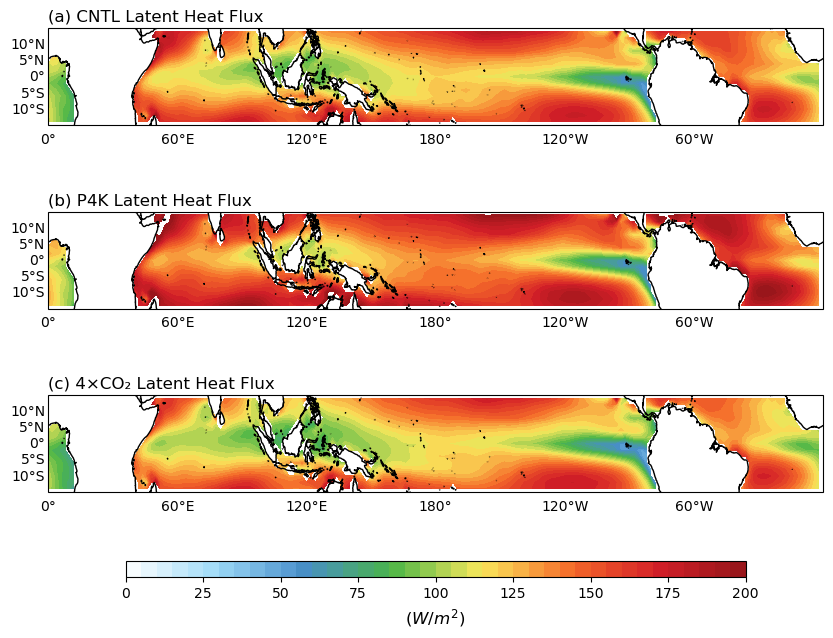

In [12]:
# 绘制潜热通量气候态图

fig, axes = plt.subplots(3, 1, figsize=(10, 9), 
                         subplot_kw={'projection': ccrs.PlateCarree(180)})

axes_all = []
# Configuration
exps = ["CNTL", "P4K", "4CO2"]
titles = ["(a) CNTL", "(b) P4K", r"(c) 4×CO₂"]
# Plot climatology for each experiment
for i, exp in enumerate(exps):
    ax = axes[i]
    # Plot (ocean only)
    im = ax.contourf(np.arange(0, 360, 2.0), 
                     np.arange(-14, 14.1, 2.0),
                     hfls_clim[exp]*(-1),
                     levels=np.linspace(0, 200, 41),
                     cmap=cmaps.WhiteBlueGreenYellowRed,
                     transform=ccrs.PlateCarree(),
                    #  extend='both'
                     )
    
    # Map settings
    ax.coastlines()
    # Add latitude lines
    ax.set_extent([0, 360, -15, 15], crs=ccrs.PlateCarree())
    ax.set_aspect(1.5)
    # Grid
    gl = ax.gridlines(draw_labels=True, linewidth=0., alpha=0.3, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    if i < 2:
        gl.right_labels = False

    ax.set_title(f'{titles[i]} Latent Heat Flux',
                 fontsize=12, pad=5,loc='left' )
    axes_all.append(ax)
# Add colorbar
cbar = plt.colorbar(im, ax=axes_all, orientation='horizontal', 
                    pad=0.1, aspect=40, shrink=0.8)
cbar.set_label(r'$(W/m^2)$', fontsize=12, )

plt.savefig(os.path.join(fig_save_dir, 'latent_flux_climatology_ocean.png'), 
            dpi=300, bbox_inches='tight')
print(f"\nFigure saved: {os.path.join(fig_save_dir, 'latent_flux_climatology_ocean.png')}")
plt.show()


### 感热通量的空间分布图


Figure saved: ./figures/Cal_MSE/sensible_flux_climatology_ocean.png


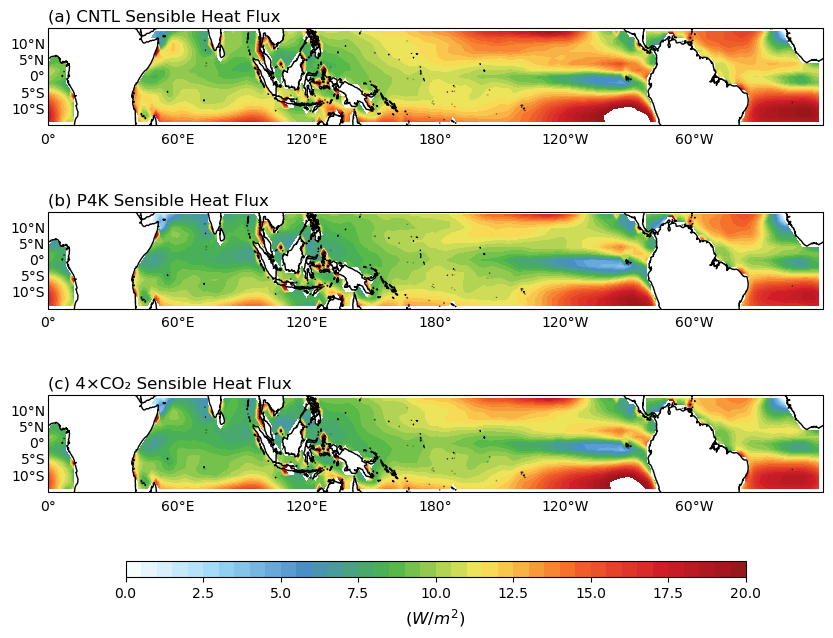

In [13]:
# 绘制潜热通量气候态图

fig, axes = plt.subplots(3, 1, figsize=(10, 9), 
                         subplot_kw={'projection': ccrs.PlateCarree(180)})

axes_all = []
# Configuration
exps = ["CNTL", "P4K", "4CO2"]
titles = ["(a) CNTL", "(b) P4K", r"(c) 4×CO₂"]
# Plot climatology for each experiment
for i, exp in enumerate(exps):
    ax = axes[i]
    # Plot (ocean only)
    im = ax.contourf(np.arange(0, 360, 2.0), 
                     np.arange(-14, 14.1, 2.0),
                     hfss_clim[exp]*(-1),
                     levels=np.linspace(0, 20, 41),
                     cmap=cmaps.WhiteBlueGreenYellowRed,
                     transform=ccrs.PlateCarree(),
                    #  extend='both'
                     )
    
    # Map settings
    ax.coastlines()
    # Add latitude lines
    ax.set_extent([0, 360, -15, 15], crs=ccrs.PlateCarree())
    ax.set_aspect(1.5)
    # Grid
    gl = ax.gridlines(draw_labels=True, linewidth=0., alpha=0.3, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    if i < 2:
        gl.right_labels = False

    ax.set_title(f'{titles[i]} Sensible Heat Flux',
                 fontsize=12, pad=5,loc='left' )
    axes_all.append(ax)
# Add colorbar
cbar = plt.colorbar(im, ax=axes_all, orientation='horizontal', 
                    pad=0.1, aspect=40, shrink=0.8)
cbar.set_label(r'$(W/m^2)$', fontsize=12, )

plt.savefig(os.path.join(fig_save_dir, 'sensible_flux_climatology_ocean.png'), 
            dpi=300, bbox_inches='tight')
print(f"\nFigure saved: {os.path.join(fig_save_dir, 'sensible_flux_climatology_ocean.png')}")
plt.show()


### 总热通量分析（潜热+感热）

In [14]:
# Calculate total surface heat flux (latent + sensible)
print("="*70)
print("Calculate Total Surface Heat Flux (Latent + Sensible)")
print("="*70)

# 1. Calculate climatology of total heat flux (up as positive)
total_flux_clim = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    # 乘以-1，使向上为正（因为原始数据中向上为负）
    total_flux_clim[exp] = hfls_clim[exp]*(-1) + hfss_clim[exp]*(-1)
    print(f"\n{exp} total flux calculated")
    print(f"   Shape: {total_flux_clim[exp].shape}")
    print(f"   Global mean: {float(total_flux_clim[exp].mean()):.2f} W/m2")

# 2. Calculate tropical mean of total heat flux
total_flux_tropical = {exp: tropical_mean(data) for exp, data in total_flux_clim.items()}

# 3. Calculate differences relative to CNTL
total_flux_diff = {
    "P4K-CNTL": total_flux_clim["P4K"] - total_flux_clim["CNTL"],
    "4CO2-CNTL": total_flux_clim["4CO2"] - total_flux_clim["CNTL"]
}


Calculate Total Surface Heat Flux (Latent + Sensible)

CNTL total flux calculated
   Shape: (15, 180)
   Global mean: 143.34 W/m2

P4K total flux calculated
   Shape: (15, 180)
   Global mean: 158.72 W/m2

4CO2 total flux calculated
   Shape: (15, 180)
   Global mean: 135.20 W/m2


In [15]:
# 应用掩膜到气候态数据
hfls_clim_ocean = {exp: data.where(ocean_mask_2deg_binary == 1) 
                   for exp, data in hfls_clim.items()}
hfss_clim_ocean = {exp: data.where(ocean_mask_2deg_binary == 1) 
                   for exp, data in hfss_clim.items()}

# 计算海洋区域的通量差异
hfls_diff_ocean = {
    "P4K-CNTL": hfls_clim_ocean["P4K"] - hfls_clim_ocean["CNTL"],
    "4CO2-CNTL": hfls_clim_ocean["4CO2"] - hfls_clim_ocean["CNTL"]
}

hfss_diff_ocean = {
    "P4K-CNTL": hfss_clim_ocean["P4K"] - hfss_clim_ocean["CNTL"],
    "4CO2-CNTL": hfss_clim_ocean["4CO2"] - hfss_clim_ocean["CNTL"]
}

Plot Total Heat Flux Climatology (Ocean Only)

Figure saved: ./figures/Cal_MSE/total_flux_climatology_ocean.png


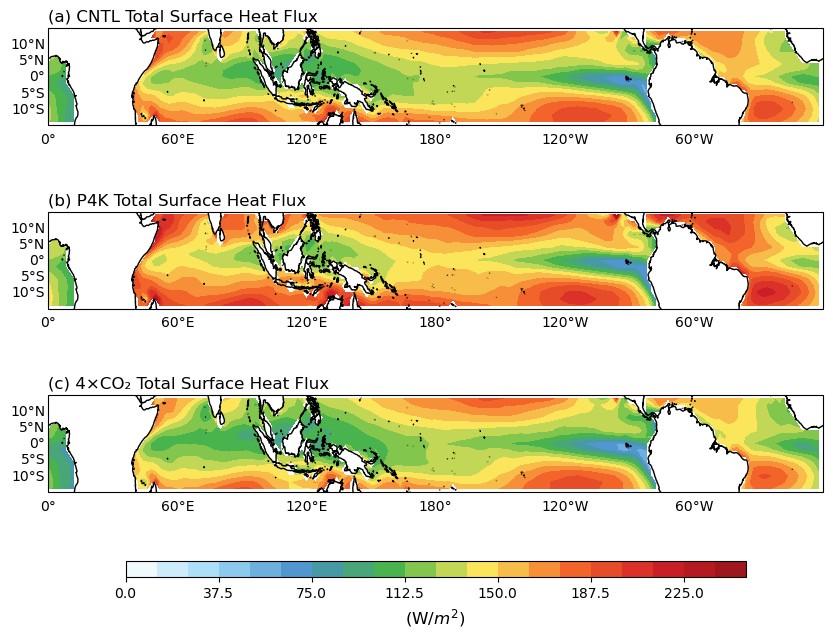

In [16]:
# Plot climatology of total surface heat flux (ocean only)
print("="*70)
print("Plot Total Heat Flux Climatology (Ocean Only)")
print("="*70)

# Calculate ocean-only total flux
total_flux_clim_ocean = {}
total_flux_tropical_ocean = {}

for exp in ["CNTL", "P4K", "4CO2"]:
    # Apply ocean mask
    total_flux_clim_ocean[exp] = total_flux_clim[exp].where(ocean_mask_2deg_binary == 1)
    # Calculate tropical mean for ocean only
    total_flux_tropical_ocean[exp] = tropical_mean(total_flux_clim_ocean[exp])

fig, axes = plt.subplots(3, 1, figsize=(10, 9), 
                         subplot_kw={'projection': ccrs.PlateCarree(180)})

axes_all = []
# Configuration
exps = ["CNTL", "P4K", "4CO2"]
titles = ["(a) CNTL", "(b) P4K", r"(c) 4×CO₂"]
# Plot climatology for each experiment
for i, exp in enumerate(exps):
    ax = axes[i]
    
    # Plot (ocean only)
    im = ax.contourf(total_flux_clim_ocean[exp].lon, 
                     total_flux_clim_ocean[exp].lat, 
                     total_flux_clim_ocean[exp],
                     levels=np.linspace(0, 250, 21),
                     cmap=cmaps.WhiteBlueGreenYellowRed,
                     transform=ccrs.PlateCarree(),
                     extend='neither')
    
    # Map settings
    ax.coastlines()
    # Add latitude lines
    ax.set_extent([0, 360, -15, 15], crs=ccrs.PlateCarree())
    ax.set_aspect(1.5)
    # Grid
    gl = ax.gridlines(draw_labels=True, linewidth=0., alpha=0.3, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    if i < 2:
        gl.right_labels = False
    
    # Title with statistics (ocean only)
    tropical_avg = float(total_flux_tropical_ocean[exp])
    global_avg = float(total_flux_clim_ocean[exp].mean())
    ax.set_title(f'{titles[i]} Total Surface Heat Flux',
                 fontsize=12, pad=5,loc='left' )
    axes_all.append(ax)
# Add colorbar
cbar = plt.colorbar(im, ax=axes_all, orientation='horizontal', 
                    pad=0.1, aspect=40, shrink=0.8)
cbar.set_label(r'(W/$m^2$)', fontsize=12, )

plt.savefig(os.path.join(fig_save_dir, 'total_flux_climatology_ocean.png'), 
            dpi=300, bbox_inches='tight')
print(f"\nFigure saved: {os.path.join(fig_save_dir, 'total_flux_climatology_ocean.png')}")
plt.show()



Figure saved: ./figures/Cal_MSE/total_flux_differences_ocean.png


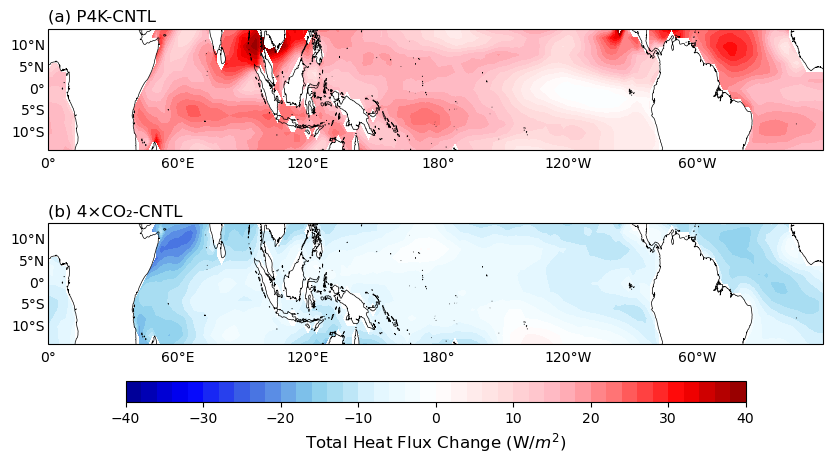

In [17]:

# Calculate ocean-only differences
total_flux_diff_ocean = {
    "P4K-CNTL": total_flux_clim_ocean["P4K"] - total_flux_clim_ocean["CNTL"],
    "4CO2-CNTL": total_flux_clim_ocean["4CO2"] - total_flux_clim_ocean["CNTL"]
}

fig, axes = plt.subplots(2, 1, figsize=(10, 6), 
                         subplot_kw={'projection': ccrs.PlateCarree(180)})
# Configuration
diffs = ["P4K-CNTL", "4CO2-CNTL"]
titles = ["(a) P4K-CNTL", "(b) 4×CO₂-CNTL"]
# Plot differences
for i, diff_name in enumerate(diffs):
    ax = axes[i]
    
    # Plot (ocean only)
    im = ax.contourf(total_flux_diff_ocean[diff_name].lon,
                     total_flux_diff_ocean[diff_name].lat,
                     total_flux_diff_ocean[diff_name],
                     levels=np.arange(-40, 41, 2),
                     cmap=mycmap,
                     transform=ccrs.PlateCarree(),
                     extend='neither')
    
    # Map settings
    ax.coastlines(linewidth=0.5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0., alpha=0.1, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    ax.set_aspect(2)
    # Title with statistics (ocean only)
    tropical_change = float(tropical_mean(total_flux_diff_ocean[diff_name]))
    global_change = float(total_flux_diff_ocean[diff_name].mean())
    ax.set_title(f'{titles[i]}',
                 fontsize=12, pad=5,loc='left' )

# Add colorbar
cbar = plt.colorbar(im, ax=axes, orientation='horizontal', 
                    pad=0.08, aspect=30, shrink=0.8)
cbar.set_label('Total Heat Flux Change (W/$m^2$)', fontsize=12, )

plt.savefig(os.path.join(fig_save_dir, 'total_flux_differences_ocean.png'), 
            dpi=300, bbox_inches='tight')
print(f"\nFigure saved: {os.path.join(fig_save_dir, 'total_flux_differences_ocean.png')}")
plt.show()

print("="*70)

In [18]:
# 计算海洋热带平均（使用up为正的约定）
exps = ["CNTL", "P4K", "4CO2"]
diff_names = ["P4K-CNTL", "4CO2-CNTL"]

# 气候态值（hfls_clim_ocean已经通过*(-1)变成正值）
# 注意：hfls_clim和hfss_clim原始是负值，total_flux_clim中已经取负号变正值
lh_clim_values = [-float(tropical_mean(hfls_clim_ocean[exp])) for exp in exps]
sh_clim_values = [-float(tropical_mean(hfss_clim_ocean[exp])) for exp in exps]
total_clim_values = [float(tropical_mean(total_flux_clim_ocean[exp])) for exp in exps]

# 差异值
lh_diff_values = [-float(tropical_mean(hfls_diff_ocean[name])) for name in diff_names]
sh_diff_values = [-float(tropical_mean(hfss_diff_ocean[name])) for name in diff_names]
total_diff_values = [float(tropical_mean(total_flux_diff_ocean[name])) for name in diff_names]

print("调整后的符号（up为正）:")
print("\n气候态值:")
for i, exp in enumerate(exps):
    print(f"{exp}: LH={lh_clim_values[i]:.1f}, SH={sh_clim_values[i]:.1f}, Total={total_clim_values[i]:.1f} W/m²")

print("\n差异值:")
for i, name in enumerate(diff_names):
    print(f"{name}: ΔLH={lh_diff_values[i]:.1f}, ΔSH={sh_diff_values[i]:.1f}, ΔTotal={total_diff_values[i]:.1f} W/m²")

调整后的符号（up为正）:

气候态值:
CNTL: LH=131.5, SH=11.9, Total=143.3 W/m²
P4K: LH=148.3, SH=10.4, Total=158.7 W/m²
4CO2: LH=124.6, SH=10.6, Total=135.2 W/m²

差异值:
P4K-CNTL: ΔLH=16.8, ΔSH=-1.5, ΔTotal=15.4 W/m²
4CO2-CNTL: ΔLH=-6.9, ΔSH=-1.2, ΔTotal=-8.1 W/m²


📊 完整综合分析：潜热、感热、总通量（3×2布局）

✅ 6-panel综合图已保存: ./figures/Cal_MSE/heat_flux_comprehensive_6panel_ocean.png


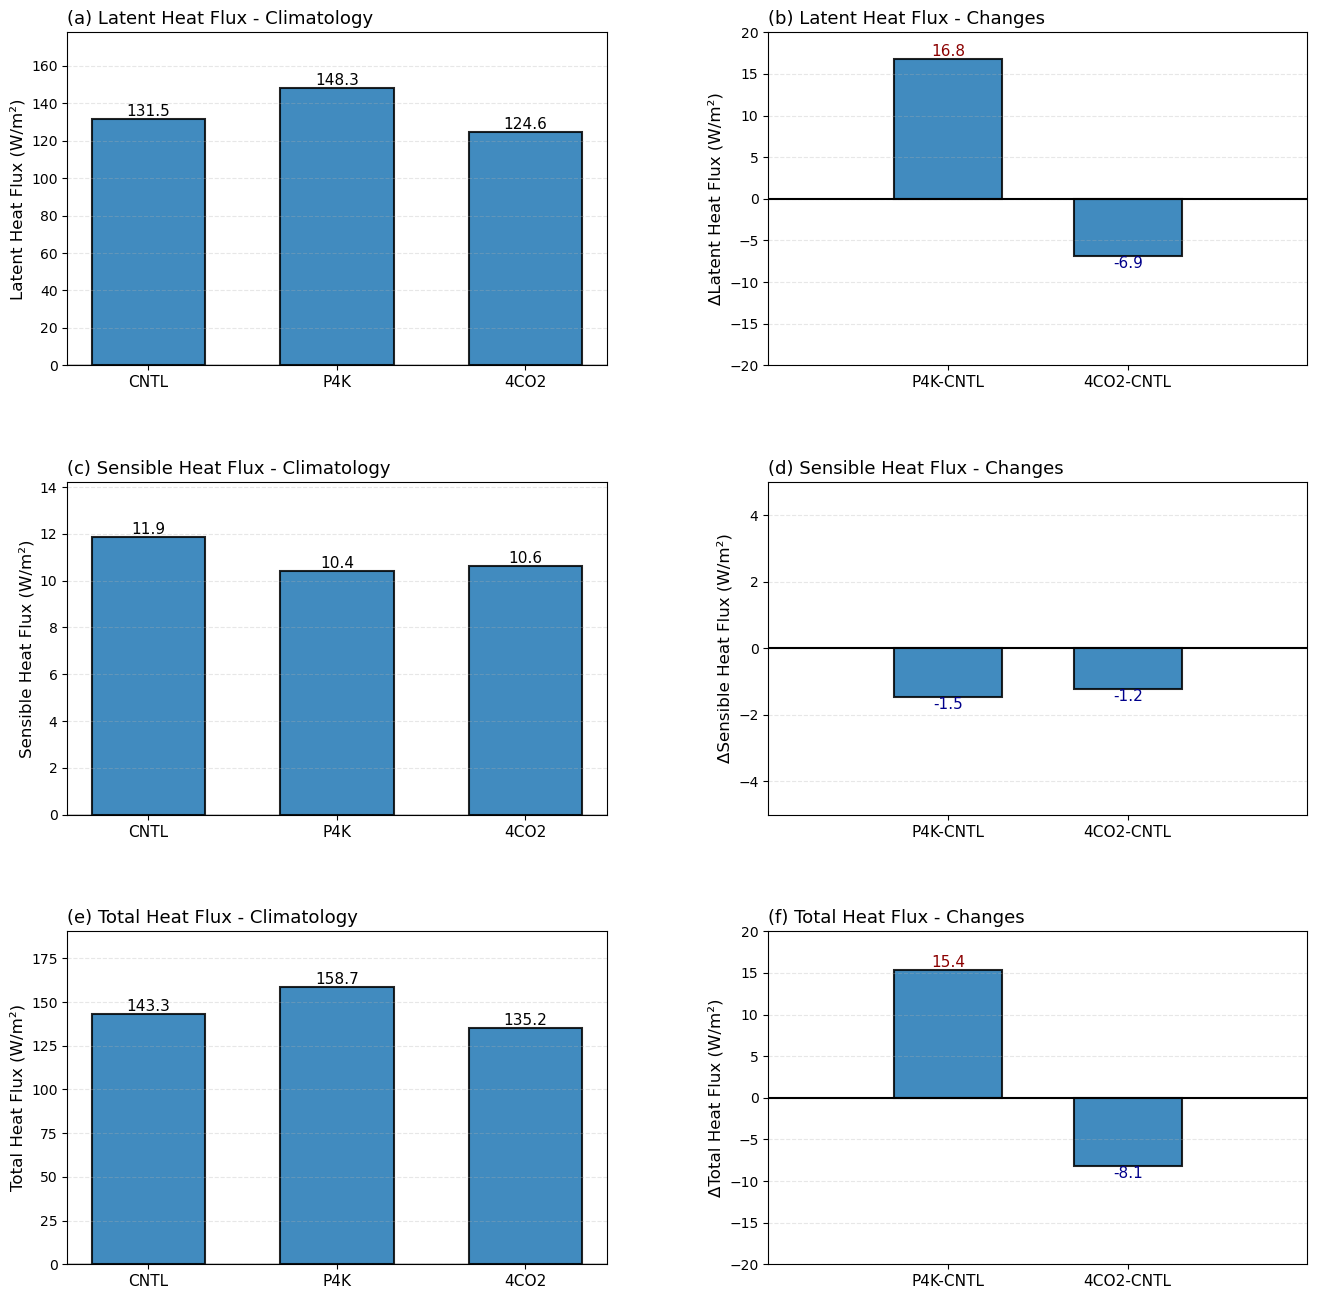


📊 数值总结（热带海洋，15°S-15°N）

【气候态】
实验         潜热(LH)          感热(SH)          总通量            
----------------------------------------------------------------------
CNTL                131.5           11.9          143.3
P4K                 148.3           10.4          158.7
4CO2                124.6           10.6          135.2

【相对CNTL的变化】
差异           Δ潜热(LH)         Δ感热(SH)         Δ总通量           
----------------------------------------------------------------------
P4K-CNTL               16.8           -1.5           15.4
4CO2-CNTL              -6.9           -1.2           -8.1

💡 关键发现:
----------------------------------------------------------------------

P4K-CNTL:
  • 潜热贡献: 109.4% (+16.8 W/m²)
  • 感热贡献: -9.4% (-1.5 W/m²)
  • 总变化: +15.4 W/m²

4CO2-CNTL:
  • 潜热贡献: 85.0% (-6.9 W/m²)
  • 感热贡献: 15.0% (-1.2 W/m²)
  • 总变化: -8.1 W/m²


In [22]:
# 完整6子图综合分析（3行2列）
print("="*70)
print("📊 完整综合分析：潜热、感热、总通量（3×2布局）")
print("="*70)
colors_exp = cmaps.WhiteBlueGreenYellowRed
colors_diff = cmaps.BlueWhiteOrangeRed
# 创建3x2子图布局
fig = plt.figure(figsize=(16, 16))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

width = 0.6

# ==================== 第1行: 潜热通量 ====================
# 左：气候态
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(len(exps))
bars1 = ax1.bar(x, lh_clim_values, width,  alpha=0.85,
                edgecolor='black', linewidth=1.5)
for bar, val in zip(bars1, lh_clim_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11)
ax1.set_ylabel('Latent Heat Flux (W/m²)', fontsize=12)
ax1.set_title('(a) Latent Heat Flux - Climatology', fontsize=13, loc='left')
ax1.set_xticks(x)
ax1.set_xticklabels(exps, fontsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
y_range = max(abs(min(lh_clim_values)), abs(max(lh_clim_values)))
ax1.set_ylim([0, y_range*1.2])

# 右：差异
ax2 = fig.add_subplot(gs[0, 1])
x2 = np.arange(len(diff_names))
bars2 = ax2.bar(x2, lh_diff_values, width,  alpha=0.85,
                edgecolor='black', linewidth=1.5)
for bar, val in zip(bars2, lh_diff_values):
    height = bar.get_height()
    color = 'darkred' if height > 0 else 'darkblue'
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11, color=color)
ax2.set_ylabel('ΔLatent Heat Flux (W/m²)', fontsize=12)
ax2.set_title('(b) Latent Heat Flux - Changes', fontsize=13, loc='left')
ax2.set_xticks(x2)
ax2.set_xticklabels(diff_names, fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax2.set_ylim(-20,20)
ax2.set_xlim(-1,2)
# ==================== 第2行: 感热通量 ====================
# 左：气候态
ax3 = fig.add_subplot(gs[1, 0])
bars3 = ax3.bar(x, sh_clim_values, width, alpha=0.85,
                edgecolor='black', linewidth=1.5)
for bar, val in zip(bars3, sh_clim_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11)
ax3.set_ylabel('Sensible Heat Flux (W/m²)', fontsize=12)
ax3.set_title('(c) Sensible Heat Flux - Climatology', fontsize=13, loc='left')
ax3.set_xticks(x)
ax3.set_xticklabels(exps, fontsize=11)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
y_range = max(abs(min(sh_clim_values)), abs(max(sh_clim_values)))
ax3.set_ylim([0, y_range*1.2])

# 右：差异
ax4 = fig.add_subplot(gs[1, 1])
bars4 = ax4.bar(x2, sh_diff_values, width,  alpha=0.85,
                edgecolor='black', linewidth=1.5)
for bar, val in zip(bars4, sh_diff_values):
    height = bar.get_height()
    color = 'darkred' if height > 0 else 'darkblue'
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11, color=color)
ax4.set_ylabel('ΔSensible Heat Flux (W/m²)', fontsize=12)
ax4.set_title('(d) Sensible Heat Flux - Changes', fontsize=13, loc='left')
ax4.set_xticks(x2)
ax4.set_xticklabels(diff_names, fontsize=11)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax4.set_ylim(-5,5)
ax4.set_xlim(-1,2)
# ==================== 第3行: 总通量 ====================
# 左：气候态
ax5 = fig.add_subplot(gs[2, 0])
bars5 = ax5.bar(x, total_clim_values, width, alpha=0.85,
                edgecolor='black', linewidth=1.5)
for bar, val in zip(bars5, total_clim_values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11)
ax5.set_ylabel('Total Heat Flux (W/m²)', fontsize=12)
ax5.set_title('(e) Total Heat Flux - Climatology', fontsize=13, loc='left')
ax5.set_xticks(x)
ax5.set_xticklabels(exps, fontsize=11)
ax5.grid(axis='y', alpha=0.3, linestyle='--')
ax5.axhline(y=0, color='black', linestyle='-', linewidth=1)
y_range = max(abs(min(total_clim_values)), abs(max(total_clim_values)))
ax5.set_ylim([0, y_range*1.2])

# 右：差异
ax6 = fig.add_subplot(gs[2, 1])
bars6 = ax6.bar(x2, total_diff_values, width,  alpha=0.85,
                edgecolor='black', linewidth=1.5)
for bar, val in zip(bars6, total_diff_values):
    height = bar.get_height()
    color = 'darkred' if height > 0 else 'darkblue'
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11, color=color)
ax6.set_ylabel('ΔTotal Heat Flux (W/m²)', fontsize=12)
ax6.set_title('(f) Total Heat Flux - Changes', fontsize=13, loc='left')
ax6.set_xticks(x2)
ax6.set_xticklabels(diff_names, fontsize=11)
ax6.grid(axis='y', alpha=0.3, linestyle='--')
ax6.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax6.set_ylim(-20,20)
ax6.set_xlim(-1,2)
# 保存图像
save_path = os.path.join(fig_save_dir, 'heat_flux_comprehensive_6panel_ocean.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ 6-panel综合图已保存: {save_path}")
plt.show()

# 打印数值总结
print("\n" + "="*70)
print("📊 数值总结（热带海洋，15°S-15°N）")
print("="*70)
print("\n【气候态】")
print(f"{'实验':<10} {'潜热(LH)':<15} {'感热(SH)':<15} {'总通量':<15}")
print("-"*70)
for i, exp in enumerate(exps):
    print(f"{exp:<10} {lh_clim_values[i]:>14.1f} {sh_clim_values[i]:>14.1f} {total_clim_values[i]:>14.1f}")

print("\n【相对CNTL的变化】")
print(f"{'差异':<12} {'Δ潜热(LH)':<15} {'Δ感热(SH)':<15} {'Δ总通量':<15}")
print("-"*70)
for i, diff in enumerate(diff_names):
    print(f"{diff:<12} {lh_diff_values[i]:>14.1f} {sh_diff_values[i]:>14.1f} {total_diff_values[i]:>14.1f}")

print("\n💡 关键发现:")
print("-"*70)
# 计算贡献百分比
for i, diff in enumerate(diff_names):
    lh_contrib = (lh_diff_values[i] / total_diff_values[i] * 100) if total_diff_values[i] != 0 else 0
    sh_contrib = (sh_diff_values[i] / total_diff_values[i] * 100) if total_diff_values[i] != 0 else 0
    print(f"\n{diff}:")
    print(f"  • 潜热贡献: {lh_contrib:.1f}% ({lh_diff_values[i]:+.1f} W/m²)")
    print(f"  • 感热贡献: {sh_contrib:.1f}% ({sh_diff_values[i]:+.1f} W/m²)")
    print(f"  • 总变化: {total_diff_values[i]:+.1f} W/m²")

print("="*70)

## 步骤4: 分析通量与EOF垂直结构的关系

In [25]:
# 步骤5.3: 加载EOF垂直结构数据
print("="*70)
print("📂 加载EOF垂直结构数据")
print("="*70)

eof_dir = "/work/mh1498/m301257/processed_data/eof_mode_decom"

# 加载三个实验的EOF结果
eof_results = {}
for exp_name in ["cntl", "p4k", "4co2"]:
    eof_file = os.path.join(eof_dir, f"eof_results_{exp_name}.pkl")
    print(f"\n🔄 加载 {exp_name.upper()} EOF数据...")
    
    with open(eof_file, 'rb') as f:
        eof_data = pickle.load(f)
    
    eof_results[exp_name.upper() if exp_name != "4co2" else "4CO2"] = eof_data
    
    # 显示数据结构
    print(f"   ✅ 成功加载")
    print(f"   数据键: {list(eof_data.keys())}")
    
    # 检查EOF模态数据
    if 'eofs' in eof_data:
        print(f"   EOF形状: {eof_data['eofs'].shape}")
    if 'explained_variance_ratio' in eof_data:
        print(f"   解释方差比: {eof_data['explained_variance_ratio'][:4]}")

print("\n" + "="*70)
print("✅ 所有EOF数据加载完成")
print("="*70)

📂 加载EOF垂直结构数据

🔄 加载 CNTL EOF数据...
   ✅ 成功加载
   数据键: ['eof_patterns', 'pc_series', 'eigenvalues', 'explained_variance', 'eigenvalue_errors', 'degrees_of_freedom', 'valid_mask', 'phi_0', 'phi_L', 'pressure_levels', 'n_harmonics', 'mask_applied', 'ocean_only', 'data_shape', 'data_dims']

🔄 加载 P4K EOF数据...
   ✅ 成功加载
   数据键: ['eof_patterns', 'pc_series', 'eigenvalues', 'explained_variance', 'eigenvalue_errors', 'degrees_of_freedom', 'valid_mask', 'phi_0', 'phi_L', 'pressure_levels', 'n_harmonics', 'mask_applied', 'ocean_only', 'data_shape', 'data_dims']

🔄 加载 4CO2 EOF数据...
   ✅ 成功加载
   数据键: ['eof_patterns', 'pc_series', 'eigenvalues', 'explained_variance', 'eigenvalue_errors', 'degrees_of_freedom', 'valid_mask', 'phi_0', 'phi_L', 'pressure_levels', 'n_harmonics', 'mask_applied', 'ocean_only', 'data_shape', 'data_dims']

✅ 所有EOF数据加载完成


In [26]:
# 检查EOF数据结构
print("="*70)
print("🔍 检查EOF数据结构")
print("="*70)

for exp in ["CNTL", "P4K", "4CO2"]:
    exp_key = exp if exp != "4CO2" else "4CO2"
    print(f"\n📊 {exp}:")
    print(f"   数据键: {list(eof_results[exp_key].keys())}")
    
    if 'eofs' in eof_results[exp_key]:
        eofs = eof_results[exp_key]['eofs']
        print(f"   EOF形状: {eofs.shape}")
        print(f"   EOF维度: {eofs.ndim}")
        print(f"   EOF数据类型: {type(eofs)}")
        
        # 如果是xarray，显示维度名
        if hasattr(eofs, 'dims'):
            print(f"   维度名称: {eofs.dims}")
            print(f"   坐标: {list(eofs.coords.keys())}")
    
    if 'explained_variance_ratio' in eof_results[exp_key]:
        var_ratio = eof_results[exp_key]['explained_variance_ratio']
        print(f"   解释方差形状: {var_ratio.shape if hasattr(var_ratio, 'shape') else len(var_ratio)}")
        print(f"   前4个模态: {var_ratio[:4]}")

print("="*70)

🔍 检查EOF数据结构

📊 CNTL:
   数据键: ['eof_patterns', 'pc_series', 'eigenvalues', 'explained_variance', 'eigenvalue_errors', 'degrees_of_freedom', 'valid_mask', 'phi_0', 'phi_L', 'pressure_levels', 'n_harmonics', 'mask_applied', 'ocean_only', 'data_shape', 'data_dims']

📊 P4K:
   数据键: ['eof_patterns', 'pc_series', 'eigenvalues', 'explained_variance', 'eigenvalue_errors', 'degrees_of_freedom', 'valid_mask', 'phi_0', 'phi_L', 'pressure_levels', 'n_harmonics', 'mask_applied', 'ocean_only', 'data_shape', 'data_dims']

📊 4CO2:
   数据键: ['eof_patterns', 'pc_series', 'eigenvalues', 'explained_variance', 'eigenvalue_errors', 'degrees_of_freedom', 'valid_mask', 'phi_0', 'phi_L', 'pressure_levels', 'n_harmonics', 'mask_applied', 'ocean_only', 'data_shape', 'data_dims']


In [27]:
# 检查eof_patterns的详细结构
print("\n" + "="*70)
print("🔍 检查 eof_patterns 详细结构")
print("="*70)

for exp in ["CNTL", "P4K", "4CO2"]:
    exp_key = exp if exp != "4CO2" else "4CO2"
    print(f"\n📊 {exp}:")
    
    if 'eof_patterns' in eof_results[exp_key]:
        eof_patterns = eof_results[exp_key]['eof_patterns']
        print(f"   类型: {type(eof_patterns)}")
        print(f"   形状: {eof_patterns.shape if hasattr(eof_patterns, 'shape') else 'N/A'}")
        
        if hasattr(eof_patterns, 'dims'):
            print(f"   维度名: {eof_patterns.dims}")
            print(f"   坐标: {list(eof_patterns.coords.keys())}")
        
        # 显示前几个值
        if hasattr(eof_patterns, 'values'):
            print(f"   数据预览: {eof_patterns.values[:2, :5] if eof_patterns.ndim > 1 else eof_patterns.values[:5]}")
        elif hasattr(eof_patterns, '__getitem__'):
            print(f"   数据预览: {eof_patterns[:2, :5] if len(eof_patterns.shape) > 1 else eof_patterns[:5]}")
    
    if 'pressure_levels' in eof_results[exp_key]:
        press_levels = eof_results[exp_key]['pressure_levels']
        print(f"   气压层数: {len(press_levels) if hasattr(press_levels, '__len__') else 'N/A'}")
        print(f"   气压范围: {press_levels[0]:.1f} - {press_levels[-1]:.1f} hPa")
    
    if 'explained_variance' in eof_results[exp_key]:
        exp_var = eof_results[exp_key]['explained_variance']
        print(f"   解释方差前4个模态: {exp_var[:4]}")

print("="*70)


🔍 检查 eof_patterns 详细结构

📊 CNTL:
   类型: <class 'numpy.ndarray'>
   形状: (22, 22)
   数据预览: [[-0.01289757 -0.0097041   0.00115777  0.023986   -0.08549391]
 [ 0.01095949 -0.00503148 -0.01056932 -0.02738654  0.05403107]]
   气压层数: 22
   气压范围: 31.0 - 90.0 hPa
   解释方差前4个模态: [55.98895923 16.28744653  6.37545799  4.34323752]

📊 P4K:
   类型: <class 'numpy.ndarray'>
   形状: (22, 22)
   数据预览: [[-0.01996275 -0.0038701   0.02282892  0.01202933 -0.27558819]
 [-0.01014274  0.00694358  0.02289297  0.01688043 -0.14333419]]
   气压层数: 22
   气压范围: 31.0 - 90.0 hPa
   解释方差前4个模态: [58.27864814 15.66341806  6.30140568  4.03317469]

📊 4CO2:
   类型: <class 'numpy.ndarray'>
   形状: (22, 22)
   数据预览: [[-0.01345573 -0.00910486  0.00258235  0.02664411 -0.10316228]
 [ 0.01015666 -0.00538763 -0.00952013 -0.02841535  0.05950974]]
   气压层数: 22
   气压范围: 31.0 - 90.0 hPa
   解释方差前4个模态: [56.45754615 15.94777917  6.18728284  4.4106842 ]


📊 创建EOF垂直结构分析图

✅ EOF垂直结构图已保存: ./figures/Cal_MSE/eof_vertical_structure.png


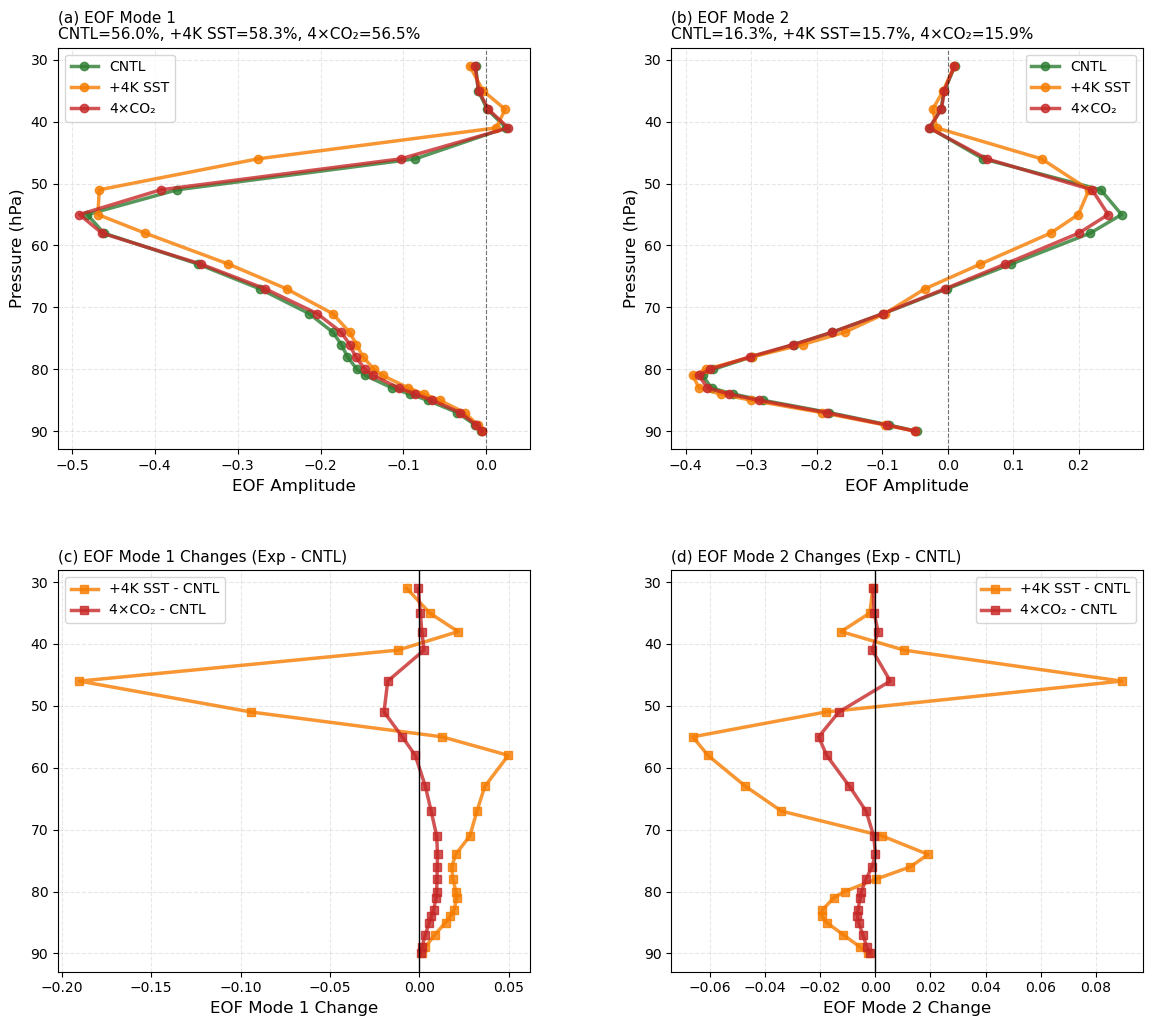

In [28]:
# 步骤5.4B: EOF垂直结构分析图（独立）
print("="*70)
print("📊 创建EOF垂直结构分析图")
print("="*70)

fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

experiments = ["CNTL", "P4K", "4CO2"]
colors = {'CNTL': '#2E7D32', 'P4K': '#F57C00', '4CO2': '#C62828'}
exp_labels = {'CNTL': 'CNTL', 'P4K': '+4K SST', '4CO2': '4×CO₂'}

# 获取气压层（从第一个实验中提取）
pressure_levels = eof_results['CNTL']['pressure_levels']

# ============= 第一行: EOF Mode 1 和 Mode 2 =============
for mode_idx in range(2):
    ax = fig.add_subplot(gs[0, mode_idx])
    
    for exp in experiments:
        exp_key = exp if exp != "4CO2" else "4CO2"
        
        try:
            # 提取EOF patterns
            eof_patterns = eof_results[exp_key]['eof_patterns']
            
            # eof_patterns 形状: (n_modes, n_levels) = (22, 22)
            # 提取第 mode_idx 个模态（第mode_idx行）
            eof_profile = eof_patterns[mode_idx, :]
            
            # 对于P4K的Mode 2，取相反数以匹配符号
            if exp == "P4K" and mode_idx == 1:
                eof_profile = -eof_profile
            
            # 绘制垂直廓线
            ax.plot(eof_profile, pressure_levels, marker='o', label=exp_labels[exp],
                   color=colors[exp], linewidth=2.5, markersize=6, alpha=0.8)
            
        except Exception as e:
            print(f"⚠️ {exp} Mode {mode_idx+1} 提取失败: {str(e)}")
            continue
    
    ax.set_xlabel('EOF Amplitude', fontsize=12, )
    ax.set_ylabel('Pressure (hPa)', fontsize=12, )
    
    # 添加解释方差
    var_strs = []
    for exp in experiments:
        exp_key = exp if exp != "4CO2" else "4CO2"
        try:
            exp_var = eof_results[exp_key]['explained_variance']
            var_pct = exp_var[mode_idx]
            var_strs.append(f"{exp_labels[exp]}={var_pct:.1f}%")
        except:
            pass
    
    title_str = f'({chr(97+mode_idx)}) EOF Mode {mode_idx+1}\n' + ', '.join(var_strs)
    ax.set_title(title_str, fontsize=11,  loc='left')
    
    ax.invert_yaxis()  # 气压从上到下递减
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=10, loc='best')
    ax.grid(alpha=0.3, linestyle='--')

# ============= 第二行: EOF Mode 1 和 Mode 2 变化分析 =============
for mode_idx in range(2):
    ax = fig.add_subplot(gs[1, mode_idx])
    
    # 计算EOF变化
    mode_changes = {}
    for exp in ["P4K", "4CO2"]:
        exp_key = exp if exp != "4CO2" else "4CO2"
        eof_cntl = eof_results['CNTL']['eof_patterns'][mode_idx, :]
        eof_exp = eof_results[exp_key]['eof_patterns'][mode_idx, :]
        
        # 对于P4K的Mode 2，先取相反数再计算差异
        if exp == "P4K" and mode_idx == 1:
            eof_exp = -eof_exp
        
        mode_changes[exp] = eof_exp - eof_cntl
    
    # 绘制变化
    for exp in ["P4K", "4CO2"]:
        ax.plot(mode_changes[exp], pressure_levels, 
                marker='s', label=f'{exp_labels[exp]} - CNTL',
                
                color=colors[exp], linewidth=2.5, markersize=6, alpha=0.8)
    
    ax.set_xlabel(f'EOF Mode {mode_idx+1} Change', fontsize=12, )
    # ax.set_ylabel('Pressure (hPa)', fontsize=12, )
    ax.set_title(f'({chr(99+mode_idx)}) EOF Mode {mode_idx+1} Changes (Exp - CNTL)', 
                fontsize=11,  loc='left')
    ax.invert_yaxis()
    ax.axvline(0, color='k', linestyle='-', linewidth=1.0)
    ax.legend(fontsize=10, loc='best')
    ax.grid(alpha=0.3, linestyle='--')



save_path = os.path.join(fig_save_dir, 'eof_vertical_structure.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✅ EOF垂直结构图已保存: {save_path}")
plt.show()

print("="*70)

✅ 海洋热通量差异图已保存到: ./figures/Cal_MSE/heat_flux_differences_ocean_only.png


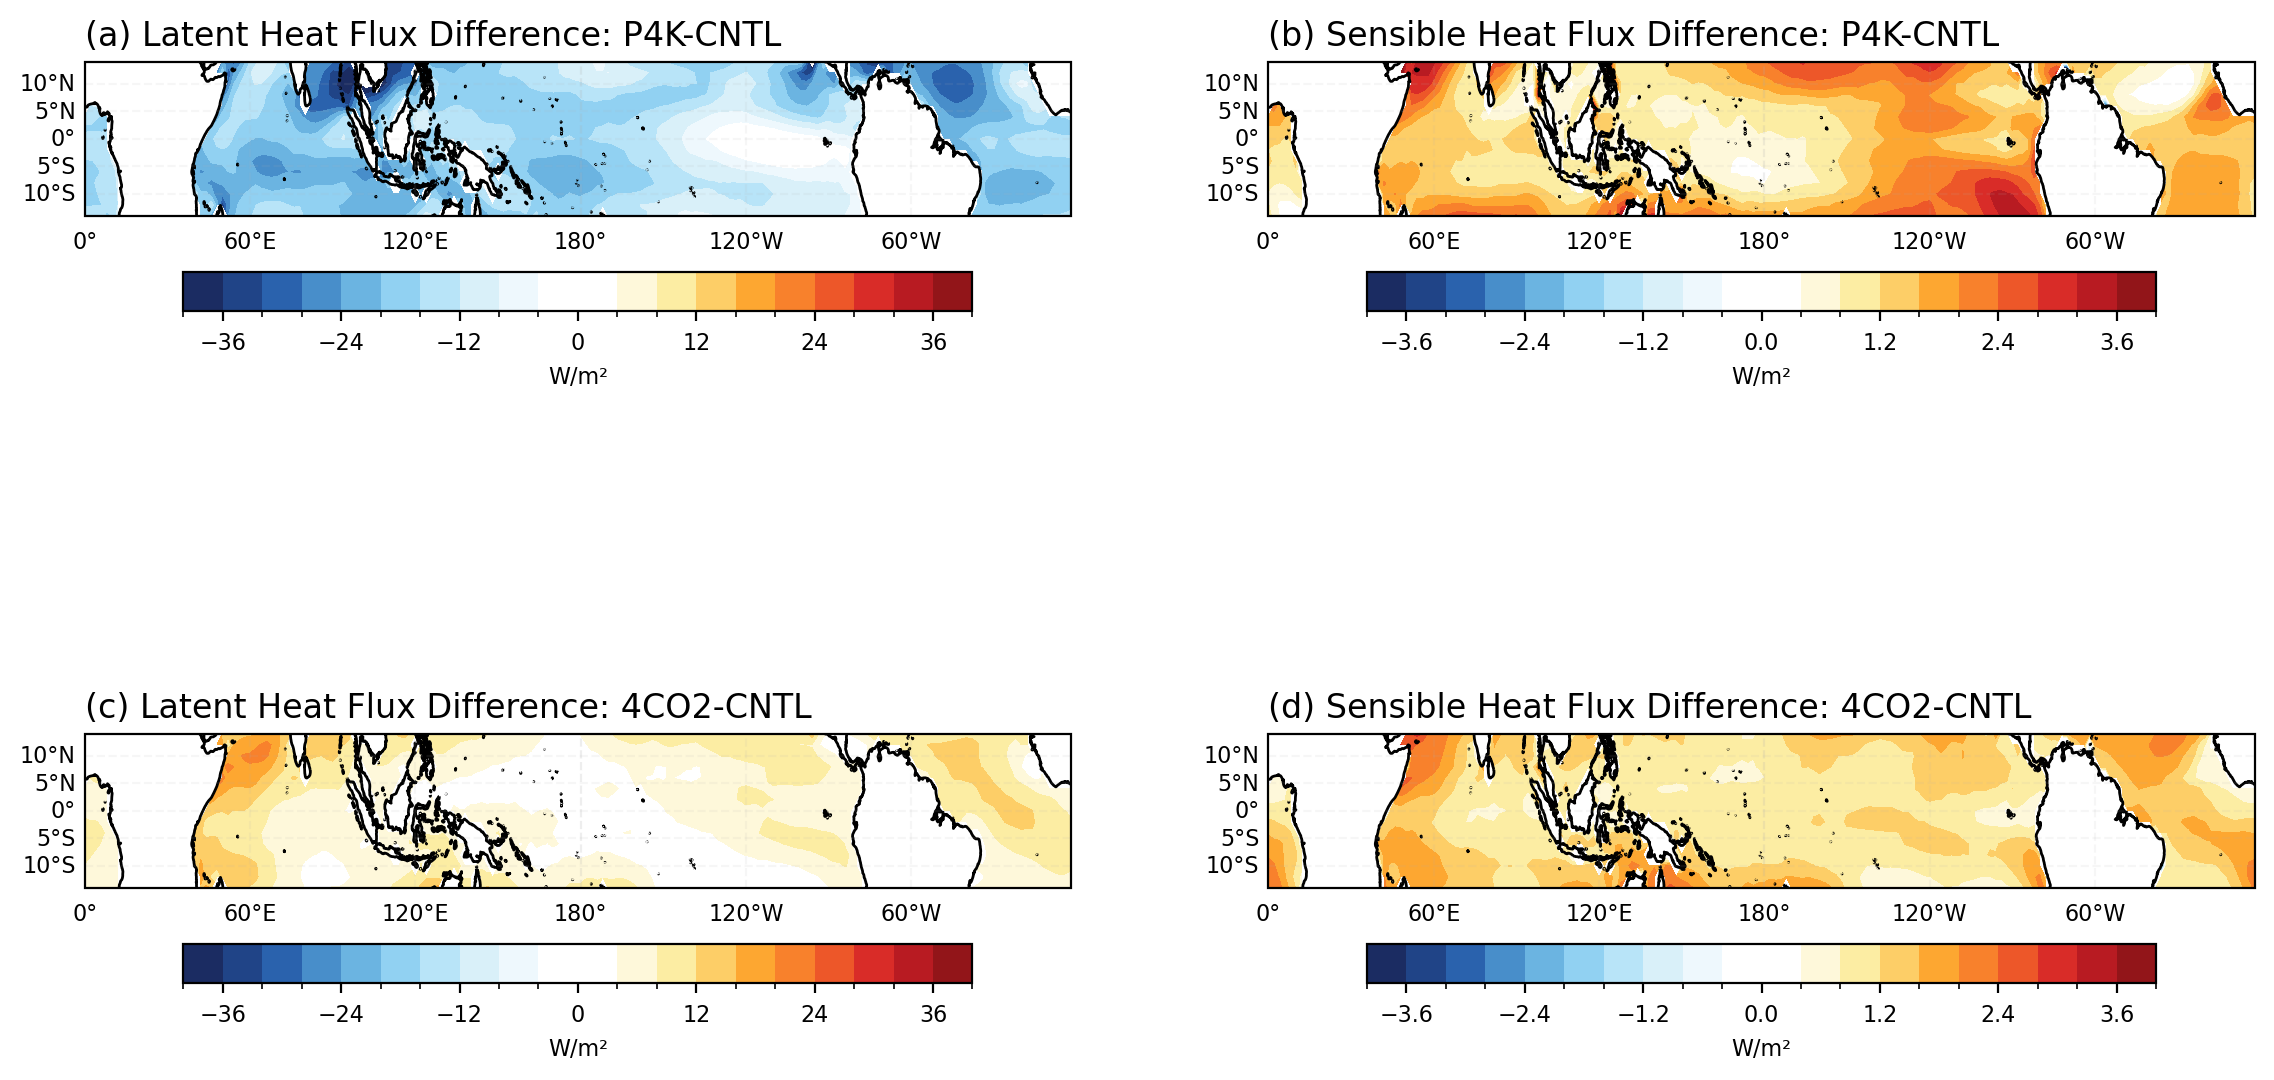


🌊 海洋热通量差异的物理解释

📊 观察到的主要特征:
   1. 潜热通量显著增加（红色区域）:
      • P4K和4CO2实验中海洋潜热通量普遍增加15-30 W/m²
      • 热带西太平洋、印度洋、大西洋暖池区增幅最大
   
   2. 感热通量变化较小（接近0）:
      • 海洋感热通量变化幅度<5 W/m²，远小于潜热通量
      • 空间分布较为均匀

🔬 物理机制:
   
   【潜热通量增加】
   ① 海表温度升高 → 饱和水汽压指数增加（Clausius-Clapeyron关系）
      e_s ∝ exp(L/R_v * 1/T)，∆SST = +4K 使 e_s 增加 ~25%
   
   ② 海气水汽压差增大 → 蒸发加强
      E = ρ * C_E * U * (q_s - q_a)
      其中 q_s(海表饱和比湿)增加，而 q_a(大气比湿)响应较慢
   
   ③ 水分供应充足 → 无水分限制
      海洋表面有无限水源，蒸发仅受能量和动力条件限制
   
   【感热通量变化小】
   ① 海洋热容大 → 温度调整缓慢
      海洋混合层深度~50-200m，热容 >> 陆地
   
   ② 海气温差变化小 → 感热通量变化小
      H = ρ * C_p * C_H * U * (T_s - T_a)
      SST和SAT同步升高，∆(T_s - T_a) ≈ 0
   
   ③ 海洋通过蒸发耗散热量 → 抑制温度升高
      蒸发增加消耗潜热 → 限制SST进一步升温

🌍 气候意义:
   • 海洋蒸发增强 → 大气水汽含量增加 → 对流活动加强
   • 潜热释放增多 → 热带对流层加热增强 → 垂直运动强度增加
   • 这一正反馈过程是热带对流组织和MJO/CCKW等波动变化的关键驱动
   • 解释了EOF Mode 1（深对流模态）振幅增强的物理基础


In [29]:



fig = plt.figure(figsize=(14, 8), dpi=200)
plt.rcParams.update({'font.size': 8})
# 绘制参数
vmin_lh, vmax_lh = -40, 40  # 潜热通量差异范围
vmin_sh, vmax_sh = -4, 4 # 感热通量差异范围

experiments_diff = ["P4K-CNTL", "4CO2-CNTL"]
# 子图标签
subplot_labels = [['(a)', '(b)'], ['(c)', '(d)']]

for i, exp_diff in enumerate(experiments_diff):
    # 潜热通量差异（仅海洋）
    ax1 = fig.add_subplot(2, 2, i*2+1, projection=ccrs.PlateCarree(180))
    im1 = hfls_diff_ocean[exp_diff].plot.contourf(
        ax=ax1, transform=ccrs.PlateCarree(), levels=np.linspace(vmin_lh, vmax_lh, 21),
        cmap=cmaps.BlueWhiteOrangeRed, extend='neither',
        add_colorbar=True, cbar_kwargs={'label': 'W/m²', 'shrink': 0.8,'orientation':'horizontal','pad':0.1}
    )
    ax1.coastlines()
    ax1.set_title(f'{subplot_labels[i][0]} Latent Heat Flux Difference: {exp_diff}', 
                  fontsize=12, loc='left')

    gl1 = ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.1)
    gl1.top_labels = False
    gl1.right_labels = False
    ax1.set_aspect(2)
    # 感热通量差异（仅海洋）
    ax2 = fig.add_subplot(2, 2, i*2+2, projection=ccrs.PlateCarree(180))
    im2 = hfss_diff_ocean[exp_diff].plot.contourf(
        ax=ax2, transform=ccrs.PlateCarree(), levels=np.linspace(vmin_sh, vmax_sh, 21),
        cmap=cmaps.BlueWhiteOrangeRed, extend='neither',
        add_colorbar=True, cbar_kwargs={'label': 'W/m²', 'shrink': 0.8,'orientation':'horizontal','pad':0.1}
    )
    ax2.coastlines()
    ax2.set_title(f'{subplot_labels[i][1]} Sensible Heat Flux Difference: {exp_diff}', 
                  fontsize=12, loc='left')

    gl2 = ax2.gridlines(draw_labels=True, linestyle='--', alpha=0.1)
    gl2.top_labels = False
    gl2.right_labels = False
    ax2.set_aspect(2)
plt.savefig(os.path.join(fig_save_dir, 'heat_flux_differences_ocean_only.png'), dpi=300, bbox_inches='tight')
print(f"✅ 海洋热通量差异图已保存到: {os.path.join(fig_save_dir, 'heat_flux_differences_ocean_only.png')}")
plt.show()

# 物理解释
print("\n" + "="*80)
print("🌊 海洋热通量差异的物理解释")
print("="*80)

print("\n📊 观察到的主要特征:")
print("   1. 潜热通量显著增加（红色区域）:")
print("      • P4K和4CO2实验中海洋潜热通量普遍增加15-30 W/m²")
print("      • 热带西太平洋、印度洋、大西洋暖池区增幅最大")
print("   ")
print("   2. 感热通量变化较小（接近0）:")
print("      • 海洋感热通量变化幅度<5 W/m²，远小于潜热通量")
print("      • 空间分布较为均匀")

print("\n🔬 物理机制:")
print("   ")
print("   【潜热通量增加】")
print("   ① 海表温度升高 → 饱和水汽压指数增加（Clausius-Clapeyron关系）")
print("      e_s ∝ exp(L/R_v * 1/T)，∆SST = +4K 使 e_s 增加 ~25%")
print("   ")
print("   ② 海气水汽压差增大 → 蒸发加强")
print("      E = ρ * C_E * U * (q_s - q_a)")
print("      其中 q_s(海表饱和比湿)增加，而 q_a(大气比湿)响应较慢")
print("   ")
print("   ③ 水分供应充足 → 无水分限制")
print("      海洋表面有无限水源，蒸发仅受能量和动力条件限制")
print("   ")
print("   【感热通量变化小】")
print("   ① 海洋热容大 → 温度调整缓慢")
print("      海洋混合层深度~50-200m，热容 >> 陆地")
print("   ")
print("   ② 海气温差变化小 → 感热通量变化小")
print("      H = ρ * C_p * C_H * U * (T_s - T_a)")
print("      SST和SAT同步升高，∆(T_s - T_a) ≈ 0")
print("   ")
print("   ③ 海洋通过蒸发耗散热量 → 抑制温度升高")
print("      蒸发增加消耗潜热 → 限制SST进一步升温")

print("\n🌍 气候意义:")
print("   • 海洋蒸发增强 → 大气水汽含量增加 → 对流活动加强")
print("   • 潜热释放增多 → 热带对流层加热增强 → 垂直运动强度增加")
print("   • 这一正反馈过程是热带对流组织和MJO/CCKW等波动变化的关键驱动")
print("   • 解释了EOF Mode 1（深对流模态）振幅增强的物理基础")

print("="*80)

In [31]:
# 步骤6.1: 加载辐射通量数据
print("="*70)
print("📊 加载辐射通量数据")
print("="*70)

# 定义辐射变量（选择最关键的变量进行分析）
rad_vars = {
    'rlut': 'TOA Outgoing Longwave (OLR)',      # 大气顶外逸长波
    'rlds': 'Surface Downwelling Longwave',     # 地表下行长波
    'rlus': 'Surface Upwelling Longwave',       # 地表上行长波
    'rsds': 'Surface Downwelling Shortwave',    # 地表下行短波
    'rsdt': 'TOA Incident Solar',               # 大气顶入射太阳辐射
    'rsut': 'TOA Outgoing Shortwave'            # 大气顶外逸短波
}

experiments = ["cntl", "p4k", "4co2"]
rad_data = {}

# 加载所有辐射数据
for var, var_name in rad_vars.items():
    print(f"\n🔄 加载 {var} ({var_name})...")
    rad_data[var] = {}
    
    for exp in experiments:
        file_path = os.path.join(LAYER_DIR, f"{var}_{exp}/{var}_2deg_interp.nc")
        
        try:
            rad_data[var][exp.upper() if exp != "4co2" else "4CO2"] = xr.open_dataarray(file_path)
            print(f"   ✅ {exp.upper()}: {rad_data[var][exp.upper() if exp != '4co2' else '4CO2'].shape}")
        except Exception as e:
            print(f"   ❌ {exp.upper()}: 加载失败 - {str(e)}")

print("\n" + "="*70)
print("✅ 辐射数据加载完成")
print("="*70)

📊 加载辐射通量数据

🔄 加载 rlut (TOA Outgoing Longwave (OLR))...
   ✅ CNTL: (5114, 15, 180)
   ✅ P4K: (5114, 15, 180)
   ✅ 4CO2: (5114, 15, 180)

🔄 加载 rlds (Surface Downwelling Longwave)...
   ✅ CNTL: (5114, 15, 180)
   ✅ P4K: (5114, 15, 180)
   ✅ 4CO2: (5114, 15, 180)

🔄 加载 rlus (Surface Upwelling Longwave)...
   ✅ CNTL: (5114, 15, 180)
   ✅ P4K: (5114, 15, 180)
   ✅ 4CO2: (5114, 15, 180)

🔄 加载 rsds (Surface Downwelling Shortwave)...
   ✅ CNTL: (5114, 15, 180)
   ✅ P4K: (5114, 15, 180)
   ✅ 4CO2: (5114, 15, 180)

🔄 加载 rsdt (TOA Incident Solar)...
   ✅ CNTL: (5114, 15, 180)
   ✅ P4K: (5114, 15, 180)
   ✅ 4CO2: (5114, 15, 180)

🔄 加载 rsut (TOA Outgoing Shortwave)...
   ✅ CNTL: (5114, 15, 180)
   ✅ P4K: (5114, 15, 180)
   ✅ 4CO2: (5114, 15, 180)

✅ 辐射数据加载完成


In [32]:
# 步骤6.2: 计算气候态和辐射通量差异
print("="*70)
print("🧮 计算辐射通量气候态和差异")
print("="*70)

# 1. 计算时间平均（气候态）
rad_clim = {}
for var in rad_vars.keys():
    rad_clim[var] = {}
    for exp in ["CNTL", "P4K", "4CO2"]:
        rad_clim[var][exp] = rad_data[var][exp].mean(dim='time')
        print(f"✅ {var} - {exp} 气候态计算完成")

# 2. 计算相对于CNTL的差异
rad_diff = {}
for var in rad_vars.keys():
    rad_diff[var] = {
        "P4K-CNTL": rad_clim[var]["P4K"] - rad_clim[var]["CNTL"],
        "4CO2-CNTL": rad_clim[var]["4CO2"] - rad_clim[var]["CNTL"]
    }

# 3. 计算热带平均（15°S-15°N）
def tropical_mean_rad(data, lat_range=(-15, 15)):
    """计算热带平均"""
    return data.sel(lat=slice(*lat_range)).mean(dim=['lat', 'lon'])

rad_tropical = {}
for var in rad_vars.keys():
    rad_tropical[var] = {exp: tropical_mean_rad(data) 
                         for exp, data in rad_clim[var].items()}

# 4. 打印辐射通量统计
print("\n" + "="*70)
print("📊 热带平均辐射通量 (W/m²)")
print("="*70)
print(f"{'变量':<8} {'CNTL':<15} {'P4K':<15} {'4CO2':<15}")
print("-"*70)

for var, var_name in rad_vars.items():
    cntl_val = float(rad_tropical[var]["CNTL"])
    p4k_val = float(rad_tropical[var]["P4K"])
    co2_val = float(rad_tropical[var]["4CO2"])
    print(f"{var:<8} {cntl_val:<15.2f} {p4k_val:<15.2f} {co2_val:<15.2f}")

print("\n" + "="*70)
print("📊 相对CNTL的辐射通量变化 (W/m²)")
print("="*70)
print(f"{'变量':<8} {'P4K-CNTL':<15} {'4CO2-CNTL':<15} {'差异(4CO2-P4K)':<15}")
print("-"*70)

rad_changes = {}
for var in rad_vars.keys():
    dp4k = float(tropical_mean_rad(rad_diff[var]["P4K-CNTL"]))
    dco2 = float(tropical_mean_rad(rad_diff[var]["4CO2-CNTL"]))
    diff_exp = dco2 - dp4k
    
    rad_changes[var] = {
        'P4K-CNTL': dp4k,
        '4CO2-CNTL': dco2,
        'diff': diff_exp
    }
    
    print(f"{var:<8} {dp4k:<15.2f} {dco2:<15.2f} {diff_exp:<15.2f}")

print("="*70)

🧮 计算辐射通量气候态和差异
✅ rlut - CNTL 气候态计算完成
✅ rlut - P4K 气候态计算完成
✅ rlut - 4CO2 气候态计算完成
✅ rlds - CNTL 气候态计算完成
✅ rlds - P4K 气候态计算完成
✅ rlds - 4CO2 气候态计算完成
✅ rlus - CNTL 气候态计算完成
✅ rlus - P4K 气候态计算完成
✅ rlus - 4CO2 气候态计算完成
✅ rsds - CNTL 气候态计算完成
✅ rsds - P4K 气候态计算完成
✅ rsds - 4CO2 气候态计算完成
✅ rsdt - CNTL 气候态计算完成
✅ rsdt - P4K 气候态计算完成
✅ rsdt - 4CO2 气候态计算完成
✅ rsut - CNTL 气候态计算完成
✅ rsut - P4K 气候态计算完成
✅ rsut - 4CO2 气候态计算完成

📊 热带平均辐射通量 (W/m²)
变量       CNTL            P4K             4CO2           
----------------------------------------------------------------------
rlut     258.09          266.37          249.76         
rlds     398.85          433.61          404.17         
rlus     457.83          484.37          458.44         
rsds     248.77          247.82          247.60         
rsdt     411.39          411.39          411.39         
rsut     93.42           88.47           92.80          

📊 相对CNTL的辐射通量变化 (W/m²)
变量       P4K-CNTL        4CO2-CNTL       差异(4CO2-P4K)   
-------------------------

In [33]:
# 步骤6.3: 计算净辐射和辐射收支
print("="*70)
print("🧮 计算净辐射和辐射收支")
print("="*70)

# 确保rsus已加载（如果rad_clim中没有rsus，需要先加载）
if 'rsus' not in rad_clim:
    print("⚠️  rsus未找到，跳过地表净短波计算")

# 计算关键的辐射平衡量
rad_budget = {}

for exp in ["CNTL", "P4K", "4CO2"]:
    rad_budget[exp] = {}
    
    # 地表净短波辐射 (吸收的太阳辐射)
    if 'rsus' in rad_clim:
        rad_budget[exp]['sfc_net_sw'] = rad_clim['rsds'][exp] - rad_clim['rsus'][exp]
    else:
        rad_budget[exp]['sfc_net_sw'] = rad_clim['rsds'][exp]  # 简化版本
    
    # 地表净长波辐射 (向上为正，向下为负 → 净长波通常为负，表示地表失去能量)
    rad_budget[exp]['sfc_net_lw'] = rad_clim['rlus'][exp] - rad_clim['rlds'][exp]
    
    # 地表净辐射 (正值表示地表获得能量)
    rad_budget[exp]['sfc_net_rad'] = rad_budget[exp]['sfc_net_sw'] - rad_budget[exp]['sfc_net_lw']
    
    # TOA净辐射 (正值表示地球系统获得能量)
    rad_budget[exp]['toa_net_rad'] = rad_clim['rsdt'][exp] - rad_clim['rsut'][exp] - rad_clim['rlut'][exp]
    
    # 大气净加热 (地表到TOA的能量差异)
    rad_budget[exp]['atm_net_heat'] = rad_budget[exp]['sfc_net_rad'] - rad_budget[exp]['toa_net_rad']

# 计算辐射收支的变化
rad_budget_diff = {}
for diff_name in ["P4K-CNTL", "4CO2-CNTL"]:
    exp_name = diff_name.split("-")[0]
    rad_budget_diff[diff_name] = {}
    
    for key in rad_budget["CNTL"].keys():
        rad_budget_diff[diff_name][key] = rad_budget[exp_name][key] - rad_budget["CNTL"][key]

# 打印结果
print("\n📊 辐射收支 - 热带平均 (W/m²)")
print("="*70)
print(f"{'项目':<25} {'CNTL':<15} {'P4K':<15} {'4CO2':<15}")
print("-"*70)

budget_labels = {
    'sfc_net_sw': '地表净短波',
    'sfc_net_lw': '地表净长波',
    'sfc_net_rad': '地表净辐射',
    'toa_net_rad': 'TOA净辐射',
    'atm_net_heat': '大气净加热'
}

for key, label in budget_labels.items():
    cntl = float(tropical_mean_rad(rad_budget["CNTL"][key]))
    p4k = float(tropical_mean_rad(rad_budget["P4K"][key]))
    co2 = float(tropical_mean_rad(rad_budget["4CO2"][key]))
    print(f"{label:<25} {cntl:<15.2f} {p4k:<15.2f} {co2:<15.2f}")

print("\n📊 辐射收支变化 (W/m²)")
print("="*70)
print(f"{'项目':<25} {'P4K-CNTL':<15} {'4CO2-CNTL':<15} {'差异':<15}")
print("-"*70)

for key, label in budget_labels.items():
    dp4k = float(tropical_mean_rad(rad_budget_diff["P4K-CNTL"][key]))
    dco2 = float(tropical_mean_rad(rad_budget_diff["4CO2-CNTL"][key]))
    print(f"{label:<25} {dp4k:<15.2f} {dco2:<15.2f} {dco2-dp4k:<15.2f}")

print("="*70)

🧮 计算净辐射和辐射收支
⚠️  rsus未找到，跳过地表净短波计算

📊 辐射收支 - 热带平均 (W/m²)
项目                        CNTL            P4K             4CO2           
----------------------------------------------------------------------
地表净短波                     248.77          247.82          247.60         
地表净长波                     58.98           50.76           54.27          
地表净辐射                     189.79          197.06          193.33         
TOA净辐射                    59.87           56.55           68.82          
大气净加热                     129.92          140.51          124.51         

📊 辐射收支变化 (W/m²)
项目                        P4K-CNTL        4CO2-CNTL       差异             
----------------------------------------------------------------------
地表净短波                     -0.95           -1.17           -0.22          
地表净长波                     -8.22           -4.71           3.51           
地表净辐射                     7.27            3.54            -3.73          
TOA净辐射                    -3.32           8.


### 🔬 关键物理意义：

**Qrad的作用：**
1. **驱动大气环流**：辐射加热不均匀 → 温度梯度 → 大气运动
2. **影响对流活动**：Qrad增加 → 大气不稳定 → 对流增强
3. **与潜热协同**：辐射加热 + 潜热释放 = 总的大气加热
4. **反映气候响应**：ΔQrad反映了气候系统对外部强迫的响应

**P4K vs 4CO2的差异：**
- **P4K**: 主要由SST升高驱动，蒸发和潜热通量变化更显著
- **4CO2**: CO₂辐射强迫主导，大气辐射加热变化更直接
- 两者对MSE和EOF结构的影响机制不同

## 步骤5: 净能量通量分析 (Net Energy Flux Analysis)

根据能量平衡方程计算和分析大气柱的净能量通量：

**进入大气柱的净能量通量：**
$$F_{net} = F_{top} - F_{sur}$$

**TOA净能量通量（进入大气）：**
$$F_{top} = S_{top}^{\downarrow} - S_{top}^{\uparrow} - R_{top}^{\uparrow}$$

其中：
- $S_{top}^{\downarrow}$ (rsdt): TOA入射短波辐射
- $S_{top}^{\uparrow}$ (rsut): TOA出射短波辐射  
- $R_{top}^{\uparrow}$ (rlut): TOA出射长波辐射

**地表净能量通量（进入大气，向上为正）：**
$$F_{sur} = S_{sur}^{\downarrow} - S_{sur}^{\uparrow} + R_{sur}^{\downarrow} - R_{sur}^{\uparrow} - E - H$$

其中：
- $S_{sur}^{\downarrow}$ (rsds): 地表向下短波辐射
- $S_{sur}^{\uparrow}$ (rsus): 地表向上短波辐射
- $R_{sur}^{\downarrow}$ (rlds): 地表向下长波辐射
- $R_{sur}^{\uparrow}$ (rlus): 地表向上长波辐射
- $E$ (hfls): 地表向上潜热通量
- $H$ (hfss): 地表向上感热通量

注意：为了保持符号一致性（向上进入大气为正），地表通量计算为：
$$F_{sur} = -(S_{sur}^{\downarrow} - S_{sur}^{\uparrow} + R_{sur}^{\downarrow} - R_{sur}^{\uparrow} - E - H)$$

In [34]:
# 步骤8.1: 加载辐射变量数据
print("="*70)
print("📂 加载辐射变量数据 (Radiation Variables)")
print("="*70)

# 定义辐射变量路径
rad_vars = {
    # TOA 变量
    'rsdt': 'TOA Incoming Shortwave Radiation',
    'rsut': 'TOA Outgoing Shortwave Radiation',  
    'rlut': 'TOA Outgoing Longwave Radiation (OLR)',
    # Surface 变量
    'rsds': 'Surface Downwelling Shortwave Radiation',
    'rsus': 'Surface Upwelling Shortwave Radiation',
    'rlds': 'Surface Downwelling Longwave Radiation',
    'rlus': 'Surface Upwelling Longwave Radiation'
}

# 加载数据
rad_data = {}
for exp_name in ["CNTL", "P4K", "4CO2"]:
    rad_data[exp_name] = {}
    print(f"\n🔄 加载 {exp_name} 辐射数据...")
    
    exp_key = "AMIP_CNTL" if exp_name == "CNTL" else (
        "P4K" if exp_name == "P4K" else "4CO2"
    )
    
    for var_name, var_desc in rad_vars.items():
        try:
            var_path = os.path.join(LAYER_DIR, f"{var_name}_{exp_name.lower()}/{var_name}_2deg_interp.nc")
            
            if os.path.exists(var_path):
                print(f"   ✅ {var_name} 从已保存文件加载")
                rad_data[exp_name][var_name] = xr.open_dataarray(var_path)
            else:
                print(f"   ⚠️  文件不存在，从原始数据加载: {var_name}")
                # 这里需要实现数据加载和插值逻辑
                # 暂时跳过，用户需要先处理数据
                print(f"   ❌ 请先运行数据预处理生成该文件")
                
            if var_name in rad_data[exp_name]:
                print(f"      形状: {rad_data[exp_name][var_name].shape}")
                
        except Exception as e:
            print(f"   ❌ 加载 {var_name} 失败: {str(e)}")

# 检查数据完整性
print("\n" + "="*70)
print("📊 数据加载汇总")
print("="*70)
for exp_name in ["CNTL", "P4K", "4CO2"]:
    loaded_vars = list(rad_data[exp_name].keys())
    print(f"{exp_name}: 已加载 {len(loaded_vars)}/7 个变量")
    if len(loaded_vars) < 7:
        missing = set(rad_vars.keys()) - set(loaded_vars)
        print(f"   缺失: {missing}")

print("="*70)

📂 加载辐射变量数据 (Radiation Variables)

🔄 加载 CNTL 辐射数据...
   ✅ rsdt 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rsut 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rlut 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rsds 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rsus 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rlds 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rlus 从已保存文件加载
      形状: (5114, 15, 180)

🔄 加载 P4K 辐射数据...
   ✅ rsdt 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rsut 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rlut 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rsds 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rsus 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rlds 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rlus 从已保存文件加载
      形状: (5114, 15, 180)

🔄 加载 4CO2 辐射数据...
   ✅ rsdt 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rsut 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rlut 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rsds 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rsus 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rlds 从已保存文件加载
      形状: (5114, 15, 180)
   ✅ rlus 从

In [35]:
# 步骤8.2: 计算净能量通量
print("="*70)
print("🧮 计算净能量通量 (Net Energy Flux)")
print("="*70)

# 计算气候态（时间平均）
rad_clim = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    rad_clim[exp] = {}
    print(f"\n计算 {exp} 气候态...")
    for var_name in rad_vars.keys():
        if var_name in rad_data[exp]:
            rad_clim[exp][var_name] = rad_data[exp][var_name].mean(dim='time')
            print(f"   ✅ {var_name}: {float(rad_clim[exp][var_name].mean()):.2f} W/m²")

# 计算 F_top (进入大气柱的TOA净通量)
# F_top = rsdt - rsut - rlut
F_top = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    if all(v in rad_clim[exp] for v in ['rsdt', 'rsut', 'rlut']):
        F_top[exp] = (rad_clim[exp]['rsdt'] - 
                      rad_clim[exp]['rsut'] - 
                      rad_clim[exp]['rlut'])
        print(f"\n{exp} F_top = {float(F_top[exp].mean()):.2f} W/m²")

# 计算 F_sur (从地表进入大气的净通量，向上为正)
# F_sur = -[(rsds - rsus) + (rlds - rlus) - hfls - hfss]
#       = -(rsds - rsus + rlds - rlus) + hfls + hfss
F_sur = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    required_vars = ['rsds', 'rsus', 'rlds', 'rlus']
    if all(v in rad_clim[exp] for v in required_vars):
        # 计算地表净辐射（向下为正）
        net_rad_sur = ((rad_clim[exp]['rsds'] - rad_clim[exp]['rsus']) +
                      (rad_clim[exp]['rlds'] - rad_clim[exp]['rlus']))
        
        # F_sur = -(net_rad_sur) + hfls + hfss (向上进入大气为正)
        F_sur[exp] = -net_rad_sur + hfls_clim[exp] + hfss_clim[exp]
        print(f"{exp} F_sur = {float(F_sur[exp].mean()):.2f} W/m²")

# 计算 F_net (进入大气柱的净能量通量)
# F_net = F_top - F_sur
F_net = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    if exp in F_top and exp in F_sur:
        F_net[exp] = F_top[exp] - F_sur[exp]
        
        print(f"\n{'='*50}")
        print(f"{exp} 能量平衡:")
        print(f"{'='*50}")
        print(f"  F_top  = {float(F_top[exp].mean()):8.2f} W/m² (TOA进入)")
        print(f"  F_sur  = {float(F_sur[exp].mean()):8.2f} W/m² (地表进入)")  
        print(f"  F_net  = {float(F_net[exp].mean()):8.2f} W/m² (大气柱净收支)")
        print(f"{'='*50}")

print("\n" + "="*70)
print("✅ 净能量通量计算完成")
print("="*70)

🧮 计算净能量通量 (Net Energy Flux)

计算 CNTL 气候态...
   ✅ rsdt: 411.39 W/m²
   ✅ rsut: 93.42 W/m²
   ✅ rlut: 258.09 W/m²
   ✅ rsds: 248.77 W/m²
   ✅ rsus: 22.74 W/m²
   ✅ rlds: 398.85 W/m²
   ✅ rlus: 457.83 W/m²

计算 P4K 气候态...
   ✅ rsdt: 411.39 W/m²
   ✅ rsut: 88.47 W/m²
   ✅ rlut: 266.37 W/m²
   ✅ rsds: 247.82 W/m²
   ✅ rsus: 22.74 W/m²
   ✅ rlds: 433.61 W/m²
   ✅ rlus: 484.37 W/m²

计算 4CO2 气候态...
   ✅ rsdt: 411.39 W/m²
   ✅ rsut: 92.80 W/m²
   ✅ rlut: 249.76 W/m²
   ✅ rsds: 247.60 W/m²
   ✅ rsus: 22.57 W/m²
   ✅ rlds: 404.17 W/m²
   ✅ rlus: 458.44 W/m²

CNTL F_top = 59.87 W/m²

P4K F_top = 56.55 W/m²

4CO2 F_top = 68.82 W/m²
CNTL F_sur = -315.24 W/m²
P4K F_sur = -337.63 W/m²
4CO2 F_sur = -311.34 W/m²

CNTL 能量平衡:
  F_top  =    59.87 W/m² (TOA进入)
  F_sur  =  -315.24 W/m² (地表进入)
  F_net  =   376.54 W/m² (大气柱净收支)

P4K 能量平衡:
  F_top  =    56.55 W/m² (TOA进入)
  F_sur  =  -337.63 W/m² (地表进入)
  F_net  =   396.17 W/m² (大气柱净收支)

4CO2 能量平衡:
  F_top  =    68.82 W/m² (TOA进入)
  F_sur  =  -311.34 W/m² (地表进入)

In [36]:
# 步骤8.3: 应用海洋mask并计算差异
print("="*70)
print("🌊 应用海洋掩膜并计算实验间差异")
print("="*70)

# 应用海洋mask
F_top_ocean = {exp: data.where(ocean_mask_2deg_binary == 1) for exp, data in F_top.items()}
F_sur_ocean = {exp: data.where(ocean_mask_2deg_binary == 1) for exp, data in F_sur.items()}
F_net_ocean = {exp: data.where(ocean_mask_2deg_binary == 1) for exp, data in F_net.items()}

# 计算热带平均（海洋）
def tropical_mean_flux(data, lat_range=(-15, 15)):
    """计算热带平均（去除NaN）"""
    return data.sel(lat=slice(*lat_range)).mean(dim=['lat', 'lon'])

print("\n海洋区域热带平均 (15°S-15°N):")
print("="*70)
print(f"{'实验':<10} {'F_top':<15} {'F_sur':<15} {'F_net':<15}")
print("-"*70)

for exp in ["CNTL", "P4K", "4CO2"]:
    ftop_mean = float(tropical_mean_flux(F_top_ocean[exp]))
    fsur_mean = float(tropical_mean_flux(F_sur_ocean[exp]))
    fnet_mean = float(tropical_mean_flux(F_net_ocean[exp]))
    print(f"{exp:<10} {ftop_mean:>14.2f} {fsur_mean:>14.2f} {fnet_mean:>14.2f}")

# 计算相对CNTL的差异（海洋）
F_top_diff_ocean = {
    "P4K-CNTL": F_top_ocean["P4K"] - F_top_ocean["CNTL"],
    "4CO2-CNTL": F_top_ocean["4CO2"] - F_top_ocean["CNTL"]
}

F_sur_diff_ocean = {
    "P4K-CNTL": F_sur_ocean["P4K"] - F_sur_ocean["CNTL"],
    "4CO2-CNTL": F_sur_ocean["4CO2"] - F_sur_ocean["CNTL"]
}

F_net_diff_ocean = {
    "P4K-CNTL": F_net_ocean["P4K"] - F_net_ocean["CNTL"],
    "4CO2-CNTL": F_net_ocean["4CO2"] - F_net_ocean["CNTL"]
}

print("\n" + "="*70)
print("实验差异（相对CNTL，海洋）:")
print("="*70)
print(f"{'差异':<12} {'ΔF_top':<15} {'ΔF_sur':<15} {'ΔF_net':<15}")
print("-"*70)

for diff_name in ["P4K-CNTL", "4CO2-CNTL"]:
    dftop = float(tropical_mean_flux(F_top_diff_ocean[diff_name]))
    dfsur = float(tropical_mean_flux(F_sur_diff_ocean[diff_name]))
    dfnet = float(tropical_mean_flux(F_net_diff_ocean[diff_name]))
    print(f"{diff_name:<12} {dftop:>14.2f} {dfsur:>14.2f} {dfnet:>14.2f}")

print("\n" + "="*70)
print("💡 物理解释:")
print("="*70)
print("• F_top > 0: TOA处大气获得能量（辐射强迫）")
print("• F_sur > 0: 地表向大气输送能量（感热+潜热-净辐射）")
print("• F_net ≈ 0: 气候平衡态，大气柱能量收支接近平衡")
print("• ΔF_net > 0: 气候扰动后大气柱净获得能量")
print("="*70)

🌊 应用海洋掩膜并计算实验间差异

海洋区域热带平均 (15°S-15°N):
实验         F_top           F_sur           F_net          
----------------------------------------------------------------------
CNTL                61.30        -315.24         376.54
P4K                 58.54        -337.63         396.17
4CO2                70.21        -311.34         381.55

实验差异（相对CNTL，海洋）:
差异           ΔF_top          ΔF_sur          ΔF_net         
----------------------------------------------------------------------
P4K-CNTL              -2.76         -22.39          19.63
4CO2-CNTL              8.91           3.90           5.00

💡 物理解释:
• F_top > 0: TOA处大气获得能量（辐射强迫）
• F_sur > 0: 地表向大气输送能量（感热+潜热-净辐射）
• F_net ≈ 0: 气候平衡态，大气柱能量收支接近平衡
• ΔF_net > 0: 气候扰动后大气柱净获得能量


📊 可视化能量通量差异空间分布（海洋）
✅ 已保存: ./figures/Cal_MSE/energy_flux_diff_P4K_CNTL_ocean.png


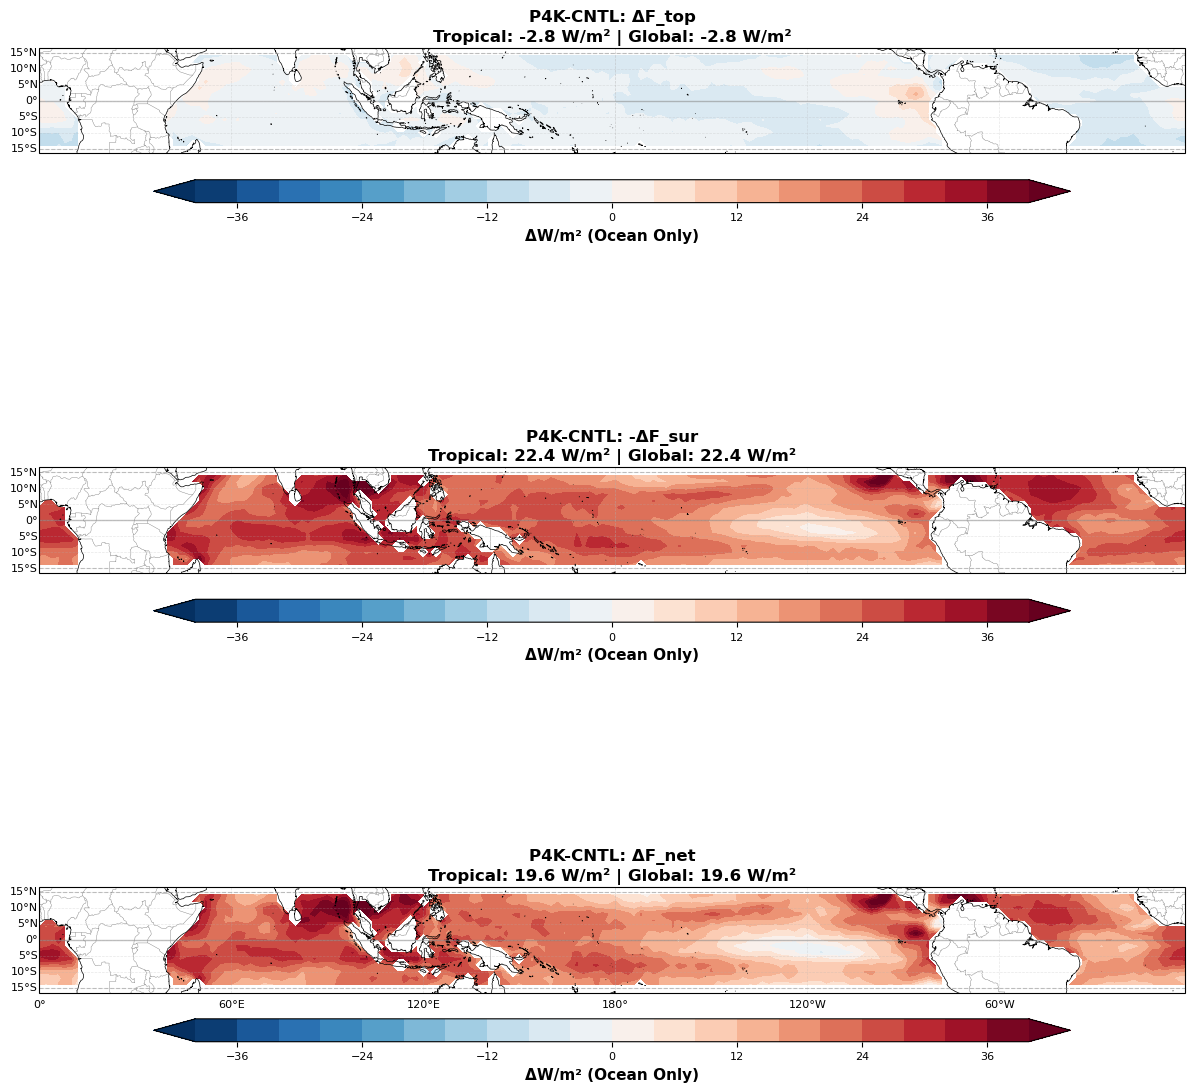

✅ 已保存: ./figures/Cal_MSE/energy_flux_diff_4CO2_CNTL_ocean.png


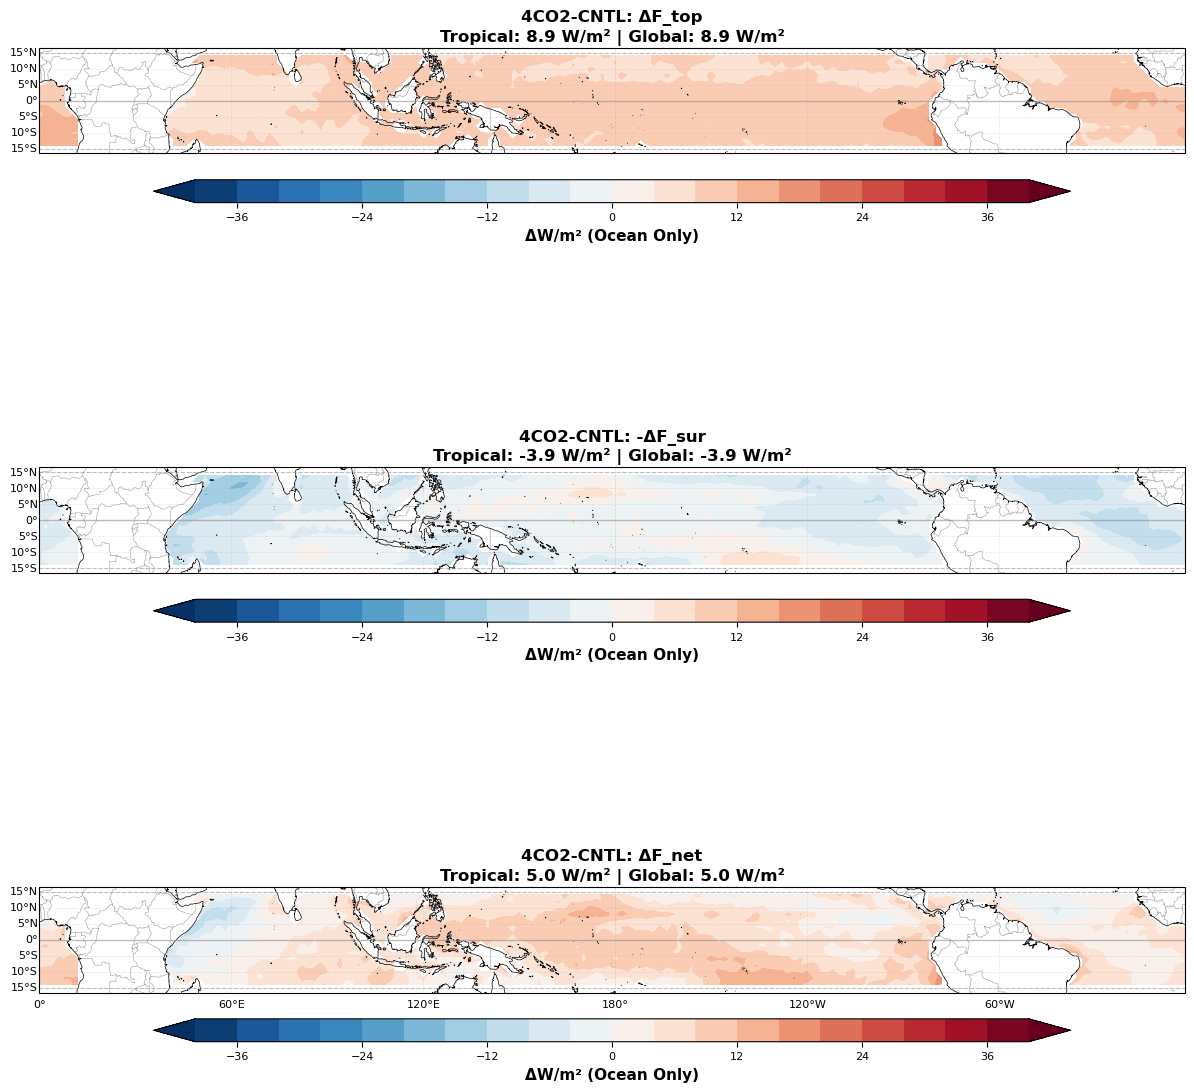

In [37]:
# 步骤8.5: 可视化实验差异 - ΔF_top, -ΔF_sur, ΔF_net (海洋)
print("="*70)
print("📊 可视化能量通量差异空间分布（海洋）")
print("="*70)

for diff_name in ["P4K-CNTL", "4CO2-CNTL"]:
    fig, axes = plt.subplots(3, 1, figsize=(12, 14), 
                             subplot_kw={'projection': ccrs.PlateCarree(180)})
    
    titles = [
        f'{diff_name}: ΔF_top',
        f'{diff_name}: -ΔF_sur',
        f'{diff_name}: ΔF_net'
    ]
    
    data_list = [
        F_top_diff_ocean[diff_name],
        -F_sur_diff_ocean[diff_name],  # 取负号
        F_net_diff_ocean[diff_name]
    ]
    
    for i, (ax, title, data) in enumerate(zip(axes, titles, data_list)):
        # 绘图
        im = ax.contourf(data.lon, data.lat, data,
                        levels=np.linspace(-40, 40, 21),
                        cmap='RdBu_r',
                        transform=ccrs.PlateCarree(),
                        extend='both')
        
        # 地图设置
        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
        
        # 添加纬度线
        ax.axhline(y=15, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axhline(y=-15, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
        
        # 网格
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.3, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        if i < 2:
            gl.bottom_labels = False
        
        # 统计值
        tropical_change = float(tropical_mean_flux(data))
        global_change = float(data.mean())
        
        ax.set_title(f'{title}\nTropical: {tropical_change:.1f} W/m² | Global: {global_change:.1f} W/m²',
                    fontsize=12, fontweight='bold', pad=5)
        
        # Colorbar
        cbar = plt.colorbar(im, ax=ax, orientation='horizontal',
                          pad=0.05, aspect=40, shrink=0.8)
        cbar.set_label('ΔW/m² (Ocean Only)', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    save_path = os.path.join(fig_save_dir, f'energy_flux_diff_{diff_name.replace("-", "_")}_ocean.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ 已保存: {save_path}")
    plt.show()

print("="*70)

📊 能量通量分量对比（柱状图）
✅ 已保存: ./figures/Cal_MSE/energy_flux_bar_comparison_ocean.png


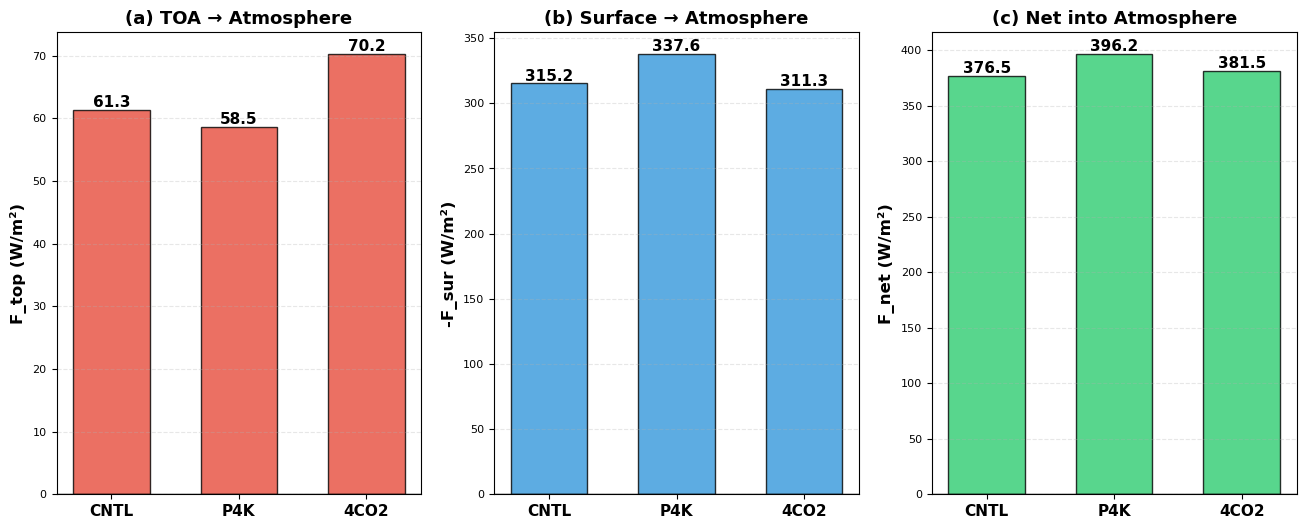

In [38]:
# 步骤8.6: 对比柱状图 - 三个实验的能量通量分量
print("="*70)
print("📊 能量通量分量对比（柱状图）")
print("="*70)

# 准备数据
exps = ["CNTL", "P4K", "4CO2"]

ftop_values = [float(tropical_mean_flux(F_top_ocean[exp])) for exp in exps]
fsur_values = [-float(tropical_mean_flux(F_sur_ocean[exp])) for exp in exps]  # 取负号
fnet_values = [float(tropical_mean_flux(F_net_ocean[exp])) for exp in exps]

# 创建图形
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

x = np.arange(len(exps))
width = 0.6

# 子图1: F_top
ax1 = axes[0]
bars1 = ax1.bar(x, ftop_values, width, color='#E74C3C', alpha=0.8, edgecolor='black')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.set_ylabel('F_top (W/m²)', fontsize=12, fontweight='bold')
ax1.set_title('(a) TOA → Atmosphere', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(exps, fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars1, ftop_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11, fontweight='bold')

# 子图2: -F_sur
ax2 = axes[1]
bars2 = ax2.bar(x, fsur_values, width, color='#3498DB', alpha=0.8, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_ylabel('-F_sur (W/m²)', fontsize=12, fontweight='bold')
ax2.set_title('(b) Surface → Atmosphere', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(exps, fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars2, fsur_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11, fontweight='bold')

# 子图3: F_net
ax3 = axes[2]
bars3 = ax3.bar(x, fnet_values, width, color='#2ECC71', alpha=0.8, edgecolor='black')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_ylabel('F_net (W/m²)', fontsize=12, fontweight='bold')
ax3.set_title('(c) Net into Atmosphere', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(exps, fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars3, fnet_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11, fontweight='bold')


save_path = os.path.join(fig_save_dir, 'energy_flux_bar_comparison_ocean.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()

print("="*70)

📊 能量通量变化对比（P4K vs 4CO2）
✅ 已保存: ./figures/Cal_MSE/energy_flux_bar_differences_ocean.png


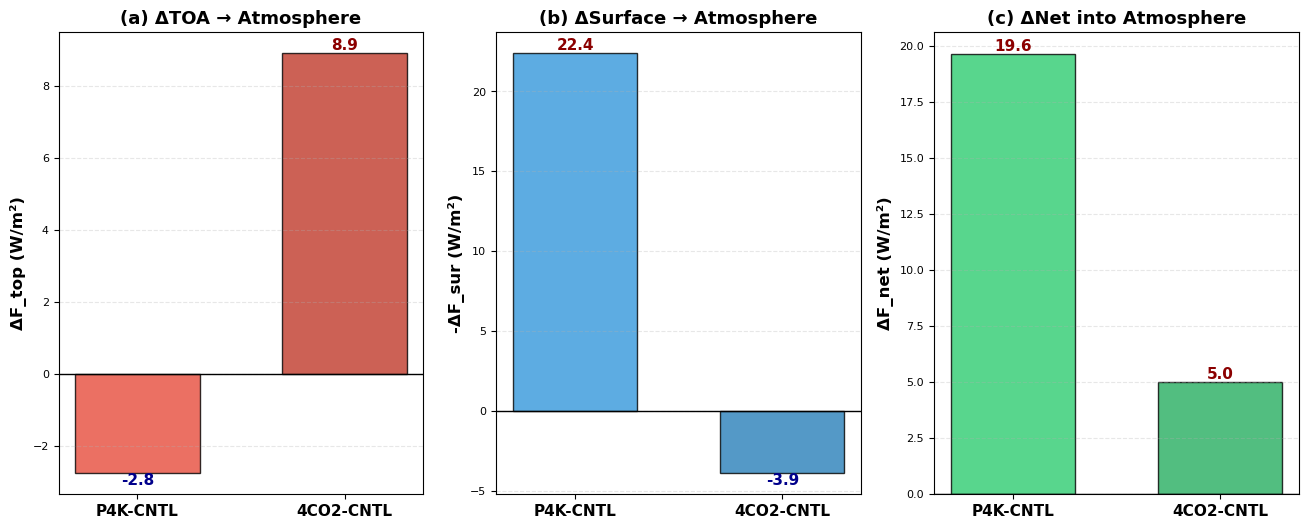

In [39]:
# 步骤8.7: 实验差异柱状图对比
print("="*70)
print("📊 能量通量变化对比（P4K vs 4CO2）")
print("="*70)

# 准备差异数据
diff_names = ["P4K-CNTL", "4CO2-CNTL"]

dftop_values = [float(tropical_mean_flux(F_top_diff_ocean[name])) for name in diff_names]
dfsur_values = [-float(tropical_mean_flux(F_sur_diff_ocean[name])) for name in diff_names]  # 取负号
dfnet_values = [float(tropical_mean_flux(F_net_diff_ocean[name])) for name in diff_names]

# 创建图形
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

x = np.arange(len(diff_names))
width = 0.6

# 子图1: ΔF_top
ax1 = axes[0]
bars1 = ax1.bar(x, dftop_values, width, color=['#E74C3C', '#C0392B'], alpha=0.8, edgecolor='black')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.set_ylabel('ΔF_top (W/m²)', fontsize=12, fontweight='bold')
ax1.set_title('(a) ΔTOA → Atmosphere', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(diff_names, fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars1, dftop_values):
    height = bar.get_height()
    color = 'darkred' if height > 0 else 'darkblue'
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11, fontweight='bold', color=color)

# 子图2: -ΔF_sur
ax2 = axes[1]
bars2 = ax2.bar(x, dfsur_values, width, color=['#3498DB', '#2980B9'], alpha=0.8, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_ylabel('-ΔF_sur (W/m²)', fontsize=12, fontweight='bold')
ax2.set_title('(b) ΔSurface → Atmosphere', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(diff_names, fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars2, dfsur_values):
    height = bar.get_height()
    color = 'darkred' if height > 0 else 'darkblue'
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11, fontweight='bold', color=color)

# 子图3: ΔF_net
ax3 = axes[2]
bars3 = ax3.bar(x, dfnet_values, width, color=['#2ECC71', '#27AE60'], alpha=0.8, edgecolor='black')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_ylabel('ΔF_net (W/m²)', fontsize=12, fontweight='bold')
ax3.set_title('(c) ΔNet into Atmosphere', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(diff_names, fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars3, dfnet_values):
    height = bar.get_height()
    color = 'darkred' if height > 0 else 'darkblue'
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11, fontweight='bold', color=color)


save_path = os.path.join(fig_save_dir, 'energy_flux_bar_differences_ocean.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()

print("="*70)

In [40]:
# 步骤8.8: 验证计算结果和物理一致性
print("="*70)
print("🔍 能量平衡验证和物理分析")
print("="*70)

print("\n1. 【能量平衡检查】")
print("="*70)
print("理论上，气候平衡态应满足: F_net ≈ 0")
print("\n各实验F_net (热带海洋平均):")
for exp in ["CNTL", "P4K", "4CO2"]:
    fnet_mean = float(tropical_mean_flux(F_net_ocean[exp]))
    print(f"  {exp}: F_net = {fnet_mean:6.2f} W/m²")

print("\n2. 【分量检查】")
print("="*70)
print("验证: F_net = F_top - F_sur")
print()
for exp in ["CNTL", "P4K", "4CO2"]:
    ftop = float(tropical_mean_flux(F_top_ocean[exp]))
    fsur = float(tropical_mean_flux(F_sur_ocean[exp]))
    fnet_calc = ftop - fsur
    fnet_direct = float(tropical_mean_flux(F_net_ocean[exp]))
    
    print(f"{exp}:")
    print(f"  F_top - F_sur = {ftop:.2f} - {fsur:.2f} = {fnet_calc:.2f} W/m²")
    print(f"  F_net (直接)  = {fnet_direct:.2f} W/m²")
    print(f"  差异 = {abs(fnet_calc - fnet_direct):.2e} W/m²")
    print()

print("3. 【气候响应分析】")
print("="*70)

for diff_name in ["P4K-CNTL", "4CO2-CNTL"]:
    print(f"\n{diff_name}:")
    dftop = float(tropical_mean_flux(F_top_diff_ocean[diff_name]))
    dfsur = float(tropical_mean_flux(F_sur_diff_ocean[diff_name]))
    dfnet = float(tropical_mean_flux(F_net_diff_ocean[diff_name]))
    
    print(f"  ΔF_top = {dftop:+7.2f} W/m² (TOA辐射强迫变化)")
    print(f"  ΔF_sur = {dfsur:+7.2f} W/m² (地表能量输入变化)")
    print(f"  ΔF_net = {dfnet:+7.2f} W/m² (大气柱净能量收支变化)")
    
    # 物理解释
    if dftop > 0:
        print(f"    → TOA处大气获得更多能量（辐射强迫增强）")
    else:
        print(f"    → TOA处大气失去更多能量（辐射冷却增强）")
        
    if dfsur > 0:
        print(f"    → 地表向大气输送更多能量（感热+潜热增强）")
    else:
        print(f"    → 地表向大气输送更少能量")
        
    if abs(dfnet) > 1:
        print(f"    ⚠️ 大气柱能量不平衡！可能处于瞬态调整过程")
    else:
        print(f"    ✅ 大气柱接近能量平衡")

print("\n" + "="*70)
print("💡 关键结论:")
print("="*70)
print("• F_top主要由TOA辐射平衡决定（短波吸收-长波辐射）")
print("• F_sur主要由地表能量平衡决定（辐射-感热-潜热）")
print("• F_net≈0 表示气候平衡态，大气柱能量收支平衡")
print("• ΔF_net显著偏离0表示气候扰动后的能量不平衡")
print("• P4K和4CO2的能量响应机制可能不同：")
print("  - P4K: SST直接升高 → 地表通量变化主导")
print("  - 4CO2: 辐射强迫 → TOA辐射平衡变化主导")
print("="*70)

🔍 能量平衡验证和物理分析

1. 【能量平衡检查】
理论上，气候平衡态应满足: F_net ≈ 0

各实验F_net (热带海洋平均):
  CNTL: F_net = 376.54 W/m²
  P4K: F_net = 396.17 W/m²
  4CO2: F_net = 381.55 W/m²

2. 【分量检查】
验证: F_net = F_top - F_sur

CNTL:
  F_top - F_sur = 61.30 - -315.24 = 376.54 W/m²
  F_net (直接)  = 376.54 W/m²
  差异 = 0.00e+00 W/m²

P4K:
  F_top - F_sur = 58.54 - -337.63 = 396.17 W/m²
  F_net (直接)  = 396.17 W/m²
  差异 = 0.00e+00 W/m²

4CO2:
  F_top - F_sur = 70.21 - -311.34 = 381.55 W/m²
  F_net (直接)  = 381.55 W/m²
  差异 = 5.68e-14 W/m²

3. 【气候响应分析】

P4K-CNTL:
  ΔF_top =   -2.76 W/m² (TOA辐射强迫变化)
  ΔF_sur =  -22.39 W/m² (地表能量输入变化)
  ΔF_net =  +19.63 W/m² (大气柱净能量收支变化)
    → TOA处大气失去更多能量（辐射冷却增强）
    → 地表向大气输送更少能量
    ⚠️ 大气柱能量不平衡！可能处于瞬态调整过程

4CO2-CNTL:
  ΔF_top =   +8.91 W/m² (TOA辐射强迫变化)
  ΔF_sur =   +3.90 W/m² (地表能量输入变化)
  ΔF_net =   +5.00 W/m² (大气柱净能量收支变化)
    → TOA处大气获得更多能量（辐射强迫增强）
    → 地表向大气输送更多能量（感热+潜热增强）
    ⚠️ 大气柱能量不平衡！可能处于瞬态调整过程

💡 关键结论:
• F_top主要由TOA辐射平衡决定（短波吸收-长波辐射）
• F_sur主要由地表能量平衡决定（辐射-感热-潜热）
• F_net≈0 表示气候平衡态，大气柱能量收